In [1]:
import jax.numpy as jnp
import neural_tangents as nt
from neural_tangents import stax
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from sklearn.model_selection import train_test_split
from jax.nn import one_hot
from tqdm import tqdm

from utils.classificationDataGeneration import make_classification_dataset, make_multitask_classification_datasets

In [2]:
def compute_infinite_ntk(kernel_fn, x_train, x_test):
    """
    Compute the empirical Neural Tangent Kernel (NTK)
    between training and test data.
    """
    
    # Compute the kernel matrices, diagonal
    ntk_train_train = kernel_fn(x_train, x_train, get='ntk', diagonal_axes=(0,))
    ntk_test_train  = kernel_fn(x_test, x_train, get='ntk', diagonal_axes=(0,))
    ntk_test_test   = kernel_fn(x_test, x_test, get='ntk')

    return {
        "train_train": ntk_train_train,
        "test_train": ntk_test_train,
        "test_test": ntk_test_test
    }

# Compute number of points needed by NTK

Our objective is to train multiple tasks and see if and where does the NTK break down in its good performance. 

The NTK computation scales quadratically in the number of data points we use to train so this represents a contraint for us. Therefore, we want to compute which is the least amount of examples we can use so that the NTK reaches a good performance. 

Here we plot the accuracy (with error bars given by different assignments of the gaussians to classes, i.e. different tasks) versus the number of points used to train.

This is for tasks that use all the gaussians, but change in random assignment to classes.

In [3]:
# Hyperparameters
num_class=2
data_dim=4
num_centers=16
dim_hypercube=2.0
possible_num_points=[15,20,30,40,50,64,128,256,512,1024,2048,4096]
num_tasks=15 # Number of tasks to average over
reg=1e-3

accs=[]
accs_std=[]

# Loop over number of points
pbar = tqdm(possible_num_points, desc="Starting", leave=False)

for num_points in pbar:

    pbar.set_description(f"Running num_points = {num_points}")

    temp_accs=[]

    for i in range(num_tasks):

        ds = make_classification_dataset(N=data_dim, K=num_centers, M=dim_hypercube, C=num_class, P=num_points, overlap=0.1, random_state=i)
        X, y = ds['X'], ds['y']
        assignment = ds['assignment']
        centers = ds['centers']
        sigma = ds['sigma']

        # Let's train test split the data
        x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

        # Transform to jax arrays
        x_train, x_test, y_trian, y_test = jnp.array(x_train), jnp.array(x_test), jnp.array(y_train), jnp.array(y_test)
        y_train = one_hot(y_train, num_class).astype(jnp.float32)
        y_test  = one_hot(y_test,  num_class).astype(jnp.float32)

        # Build network, any width is fine, by using kernel_fn it takes the infinite width anyways
        init_fn, apply_fn, kernel_fn = stax.serial(
            stax.Dense(10, W_std=1.5, b_std=0.05, parameterization="ntk"),
            stax.Erf(),
            stax.Dense(num_class, W_std=1.5, b_std=0.05, parameterization="ntk")
        )

        # Compute Infinite-width NTK
        ntk_dict_inf = compute_infinite_ntk(kernel_fn, x_train, x_test)
        K_train_train_inf = ntk_dict_inf["train_train"]
        K_test_train_inf = ntk_dict_inf["test_train"]

        # Expand to (n_train, n_train, C, C) from (n_train, n_train) with independent outputs
        K_train_train_inf = jnp.stack([jnp.stack([K_train_train_inf if i==j else jnp.zeros_like(K_train_train_inf)
                                                for j in range(num_class)], axis=-1)
                                        for i in range(num_class)], axis=-2)

        K_test_train_inf = jnp.stack([jnp.stack([K_test_train_inf if i==j else jnp.zeros_like(K_test_train_inf)
                                                for j in range(num_class)], axis=-1)
                                    for i in range(num_class)], axis=-2)

        # Gradient descent predictor
        predict_fn_inf = nt.predict.gradient_descent_mse(
            K_train_train_inf, y_train,
            diag_reg=reg, trace_axes=(), diag_reg_absolute_scale=False
        )

        # Zero initial outputs are fine in the infinite case
        fx_train_0_inf = jnp.zeros_like(y_train)
        fx_test_0_inf = jnp.zeros_like(y_test)

        _, preds_test_inf = predict_fn_inf(
            t=None, fx_train_0=fx_train_0_inf, fx_test_0=fx_test_0_inf,
            k_test_train=K_test_train_inf
        )

        # Compute infinite-width accuracy
        pred_labels_inf = jnp.argmax(preds_test_inf, axis=-1)
        true_labels = jnp.argmax(y_test, axis=-1)
        acc_inf = float(jnp.mean(pred_labels_inf == true_labels))
        temp_accs.append(acc_inf)

    accs.append(jnp.mean(jnp.array(temp_accs)))
    accs_std.append(jnp.std(jnp.array(temp_accs)))

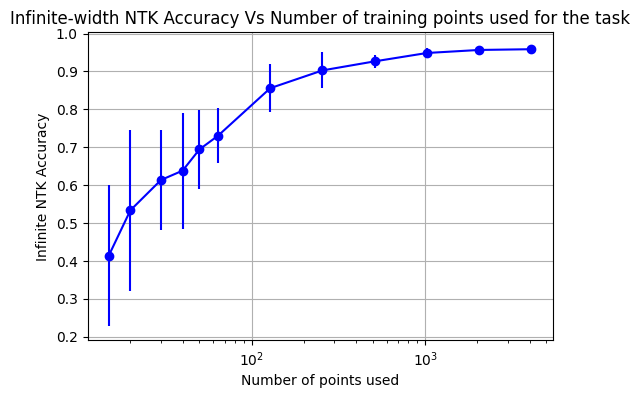

In [4]:
plt.figure(figsize=(6,4))
plt.errorbar(possible_num_points, accs, yerr=accs_std, marker='o',
             color='blue')
plt.xscale('log')
plt.xlabel('Number of points used')
plt.ylabel('Infinite NTK Accuracy')
plt.title('Infinite-width NTK Accuracy Vs Number of training points used for the task')
plt.grid(True)
plt.show()

By using 16 gaussians in 2D (square with 4 gaussians per side) we see that 50 points are usually enough to learn the task.

Note that only 33 are actually used for training and the rest are used for test.

The average accuracy for this number of data points is around 90% +- 5% circa.

# Using unique gaussians for each task

However, during multitasking, if each gaussian is not unique to a task, we need rule inputs for each task. These are technically expanding dimensions and creating different gaussians altogether anyways so from now on we create tasks by assigning a certain number of UNIQUE gaussians to each.

Since our next experiment is to see what happens when training many tasks and we will use a range of range(1,20) tasks, we want to create the least trivial tasks for it and therefore we use the highest number of centers_per_task each, which will be num_centers//19.

Finally, we need to increase the number of centers because since each task is only using 1/20 of the total centers we need many of them to make it non-trivial.

In [5]:
# Hyperparameters
num_class = 2
data_dim = 2
num_centers = 20 ** data_dim
possible_num_points = [15, 20, 30, 40, 50, 64, 128, 256, 512, 1024, 2048, 4096]
num_tasks = 15
dim_hypercube = 2.0
centers_per_task = (num_centers // 19) - 1
regs = [1e-1, 1e-2, 1e-3, 1e-4]  # Regularization sweep

# Storage
results = {reg_val: {"accs": [], "accs_std": []} for reg_val in regs}

pbar = tqdm(possible_num_points, desc="Starting", leave=False)

for num_points_per_task in pbar:
    pbar.set_description(f"P = {num_points_per_task}")

    for reg_value in regs:
        temp_accs = []

        for seed in range(num_tasks):
            # Generate multitask dataset (1 task per seed)
            ds_list = make_multitask_classification_datasets(
                data_dim=data_dim,
                num_centers=num_centers,
                dim_hypercube=dim_hypercube,
                num_class=num_class,
                num_points_per_task=num_points_per_task,
                num_tasks=1,
                centers_per_task=centers_per_task,
                overlap=0.1,
                random_state=seed,
                reuse=False
            )

            ds = ds_list[0]  # Extract task
            X, y = ds['X'], ds['y']

            x_train, x_test, y_train, y_test = train_test_split(
                X, y, test_size=0.33, random_state=42
            )

            x_train, x_test = jnp.array(x_train), jnp.array(x_test)
            y_train, y_test = jnp.array(y_train), jnp.array(y_test)

            y_train = one_hot(y_train, num_class).astype(jnp.float32)
            y_test  = one_hot(y_test,  num_class).astype(jnp.float32)

            # Build network
            init_fn, apply_fn, kernel_fn = stax.serial(
                stax.Dense(10, W_std=1.5, b_std=0.05, parameterization="ntk"),
                stax.Erf(),
                stax.Dense(num_class, W_std=1.5, b_std=0.05, parameterization="ntk")
            )

            # Infinite-width NTK
            ntk_dict_inf = compute_infinite_ntk(kernel_fn, x_train, x_test)
            K_train_train_inf = ntk_dict_inf["train_train"]
            K_test_train_inf = ntk_dict_inf["test_train"]

            # Expand kernels for multiple outputs
            K_train_train_inf = jnp.stack([
                jnp.stack([
                    K_train_train_inf if i == j else jnp.zeros_like(K_train_train_inf)
                    for j in range(num_class)
                ], axis=-1)
                for i in range(num_class)
            ], axis=-2)

            K_test_train_inf = jnp.stack([
                jnp.stack([
                    K_test_train_inf if i == j else jnp.zeros_like(K_test_train_inf)
                    for j in range(num_class)
                ], axis=-1)
                for i in range(num_class)
            ], axis=-2)

            # Gradient descent predictor
            predict_fn_inf = nt.predict.gradient_descent_mse(
                K_train_train_inf, y_train,
                diag_reg=reg_value, trace_axes=(), diag_reg_absolute_scale=False
            )

            fx_train_0_inf = jnp.zeros_like(y_train)
            fx_test_0_inf = jnp.zeros_like(y_test)

            _, preds_test_inf = predict_fn_inf(
                t=None, fx_train_0=fx_train_0_inf, fx_test_0=fx_test_0_inf,
                k_test_train=K_test_train_inf
            )

            # Accuracy
            pred_labels_inf = jnp.argmax(preds_test_inf, axis=-1)
            true_labels = jnp.argmax(y_test, axis=-1)
            acc_inf = float(jnp.mean(pred_labels_inf == true_labels))
            temp_accs.append(acc_inf)

        # Store mean/std
        results[reg_value]["accs"].append(jnp.mean(jnp.array(temp_accs)))
        results[reg_value]["accs_std"].append(jnp.std(jnp.array(temp_accs)))

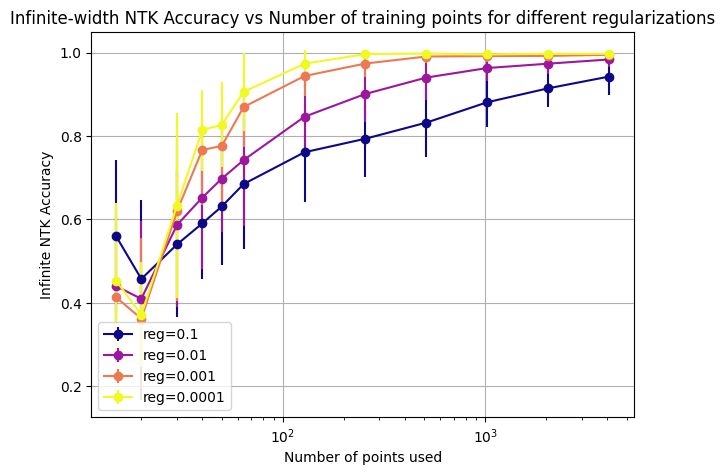

In [6]:
plt.figure(figsize=(7,5))
colors = cm.plasma(jnp.linspace(0, 1, len(regs)))

for i, reg_value in enumerate(regs):
    accs = results[reg_value]["accs"]
    accs_std = results[reg_value]["accs_std"]
    plt.errorbar(
        possible_num_points, accs, yerr=accs_std, 
        marker='o', color=colors[i], label=f'reg={reg_value}'
    )

plt.xscale('log')
plt.xlabel('Number of points used')
plt.ylabel('Infinite NTK Accuracy')
plt.title('Infinite-width NTK Accuracy vs Number of training points for different regularizations')
plt.grid(True)
plt.legend()
plt.show()


In [7]:
num_class = 2
data_dim = 2
num_centers = 20 ** data_dim        
possible_num_points = [15, 20, 30, 40, 50, 64, 128, 256, 512, 1024, 2048, 4096]
num_tasks = 15                      # Number of random seeds to avg data over
dim_hypercube = 2.0
centers_per_task = (num_centers//19) -1      # The -1 is to have an even number (needs to be divisible by num_class)
reg = 1e-4

accs = []
accs_std = []

pbar = tqdm(possible_num_points, desc="Starting", leave=False)

for num_points_per_task in pbar:
    pbar.set_description(f"Running P = {num_points_per_task}")
    temp_accs = []

    for seed in range(num_tasks):

        # Generate dataset
        ds_list = make_multitask_classification_datasets(
            data_dim=data_dim,
            num_centers=num_centers,
            dim_hypercube=dim_hypercube,
            num_class=num_class,
            num_points_per_task=num_points_per_task,
            num_tasks=1,                     # One task only
            centers_per_task=centers_per_task,
            overlap=0.1,
            random_state=seed,
            reuse=False
        )

        ds = ds_list[0]                     # Extract the task
        X, y = ds['X'], ds['y']
        centers = ds['centers']
        sigma = ds['sigma']

        x_train, x_test, y_train, y_test = train_test_split(
            X, y, test_size=0.33, random_state=42
        )

        x_train, x_test = jnp.array(x_train), jnp.array(x_test)
        y_train, y_test = jnp.array(y_train), jnp.array(y_test)

        y_train = one_hot(y_train, num_class).astype(jnp.float32)
        y_test  = one_hot(y_test,  num_class).astype(jnp.float32)

        init_fn, apply_fn, kernel_fn = stax.serial(
            stax.Dense(10, W_std=1.5, b_std=0.05, parameterization="ntk"),
            stax.Erf(),
            stax.Dense(num_class, W_std=1.5, b_std=0.05, parameterization="ntk")
        )

        ntk_dict_inf = compute_infinite_ntk(kernel_fn, x_train, x_test)
        K_train_train_inf = ntk_dict_inf["train_train"]
        K_test_train_inf = ntk_dict_inf["test_train"]

        # Expand the kernels
        K_train_train_inf = jnp.stack([
            jnp.stack([
                K_train_train_inf if i == j else jnp.zeros_like(K_train_train_inf)
                for j in range(num_class)
            ], axis=-1)
            for i in range(num_class)
        ], axis=-2)

        K_test_train_inf = jnp.stack([
            jnp.stack([
                K_test_train_inf if i == j else jnp.zeros_like(K_test_train_inf)
                for j in range(num_class)
            ], axis=-1)
            for i in range(num_class)
        ], axis=-2)

        predict_fn_inf = nt.predict.gradient_descent_mse(
            K_train_train_inf, y_train,
            diag_reg=reg, trace_axes=(), diag_reg_absolute_scale=False
        )

        fx_train_0_inf = jnp.zeros_like(y_train)
        fx_test_0_inf = jnp.zeros_like(y_test)

        _, preds_test_inf = predict_fn_inf(
            t=None, fx_train_0=fx_train_0_inf, fx_test_0=fx_test_0_inf,
            k_test_train=K_test_train_inf
        )

        pred_labels_inf = jnp.argmax(preds_test_inf, axis=-1)
        true_labels = jnp.argmax(y_test, axis=-1)
        acc_inf = float(jnp.mean(pred_labels_inf == true_labels))

        temp_accs.append(acc_inf)

    accs.append(jnp.mean(jnp.array(temp_accs)))
    accs_std.append(jnp.std(jnp.array(temp_accs)))


In [8]:
x_points_vs_acc=[points for points in possible_num_points]
y_points_vs_acc=accs
y_err_points_vs_acc=accs_std

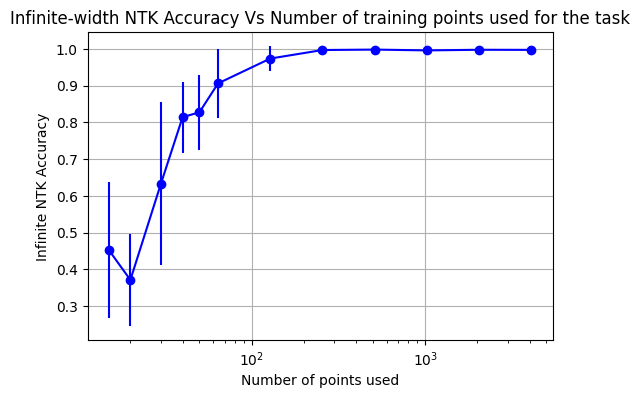

In [9]:
plt.figure(figsize=(6,4))
plt.errorbar(x_points_vs_acc, accs, yerr=accs_std, marker='o',
             color='blue')
plt.xscale('log')
plt.xlabel('Number of points used')
plt.ylabel('Infinite NTK Accuracy')
plt.title('Infinite-width NTK Accuracy Vs Number of training points used for the task')
plt.grid(True)
plt.show()

Once again, it looks like 50 points is still a good amount for this setting. We'll move ahead with it.

# How many tasks can we learn simultaneously?

In [ ]:
# Hyperparameters
possible_num_tasks = range(1, 20)
num_seeds = 10
num_points_per_task = 64   # obtained from previous analysis
num_class = 2
data_dim = 2
num_centers = 20 ** data_dim
dim_hypercube = 2.0
centers_per_task = num_centers // possible_num_tasks[-1] - 1

# Regularization sweep
regs = [10**(-i) for i in range(5)]  # 1, 1e-1, 1e-2, ...

# Preallocate results
results = {
    reg_val: {"accs": [ [] for _ in possible_num_tasks ]} 
    for reg_val in regs
}

pbar_seeds = tqdm(range(num_seeds), desc="Seeds", leave=False)

for seed in pbar_seeds:
    pbar_seeds.set_description(f"Seed = {seed}")

    # Generate one dataset with the MAX number of tasks

    max_tasks = possible_num_tasks[-1]

    ds_full = make_multitask_classification_datasets(
        data_dim=data_dim,
        num_centers=num_centers,
        dim_hypercube=dim_hypercube, 
        num_class=num_class, 
        num_points_per_task=num_points_per_task, 
        num_tasks=max_tasks,
        centers_per_task=centers_per_task, 
        overlap=0.1, 
        random_state=seed,
        reuse=False
    )

    # Loop over num_tasks and regularization values
    
    for t_idx, num_tasks in enumerate(possible_num_tasks):

        # Select the first num_tasks tasks
        ds = ds_full[:num_tasks]

        # Create combined dataset
        X_all = jnp.vstack([task['X'] for task in ds])
        y_all = jnp.concatenate([task['y'] for task in ds])

        train_test = train_test_split(
            X_all, y_all, test_size=0.33, random_state=42
        )
        x_train, x_test, y_train, y_test = map(jnp.array, train_test)

        y_train = one_hot(y_train, num_class).astype(jnp.float32)
        y_test  = one_hot(y_test,  num_class).astype(jnp.float32)

        # Build model
        init_fn, apply_fn, kernel_fn = stax.serial(
            stax.Dense(10, W_std=1.5, b_std=0.05, parameterization="ntk"),
            stax.Erf(),
            stax.Dense(num_class, W_std=1.5, b_std=0.05, parameterization="ntk")
        )

        # Compute infinite NTK
        ntk_dict_inf = compute_infinite_ntk(kernel_fn, x_train, x_test)
        K_train_train_inf = ntk_dict_inf["train_train"]
        K_test_train_inf  = ntk_dict_inf["test_train"]

        # Expand kernels for multi-output
        def expand(K):
            return jnp.stack([
                jnp.stack([
                    K if i == j else jnp.zeros_like(K)
                    for j in range(num_class)
                ], axis=-1)
                for i in range(num_class)
            ], axis=-2)

        K_train_train_inf = expand(K_train_train_inf)
        K_test_train_inf  = expand(K_test_train_inf)

        # Loop over regularization sweep
        
        for reg_value in regs:

            # Infinite-width predictor
            predict_fn_inf = nt.predict.gradient_descent_mse(
                K_train_train_inf, y_train,
                diag_reg=reg_value, trace_axes=(),
                diag_reg_absolute_scale=False
            )

            fx_train_0_inf = jnp.zeros_like(y_train)
            fx_test_0_inf  = jnp.zeros_like(y_test)

            _, preds_test_inf = predict_fn_inf(
                t=None,
                fx_train_0=fx_train_0_inf,
                fx_test_0=fx_test_0_inf,
                k_test_train=K_test_train_inf
            )

            # Accuracy
            pred_labels = jnp.argmax(preds_test_inf, axis=-1)
            true_labels = jnp.argmax(y_test, axis=-1)
            acc = float(jnp.mean(pred_labels == true_labels))

            # Store accuracy *for this seed*
            results[reg_value]["accs"][t_idx].append(acc)

# Final aggregation: compute mean & std across seeds
final_results = {}
for reg in regs:
    mean_accs = [float(jnp.mean(jnp.array(acc_list)))
                 for acc_list in results[reg]["accs"]]
    std_accs  = [float(jnp.std(jnp.array(acc_list)))
                 for acc_list in results[reg]["accs"]]

    final_results[reg] = {
        "accs_mean": mean_accs,
        "accs_std":  std_accs
    }


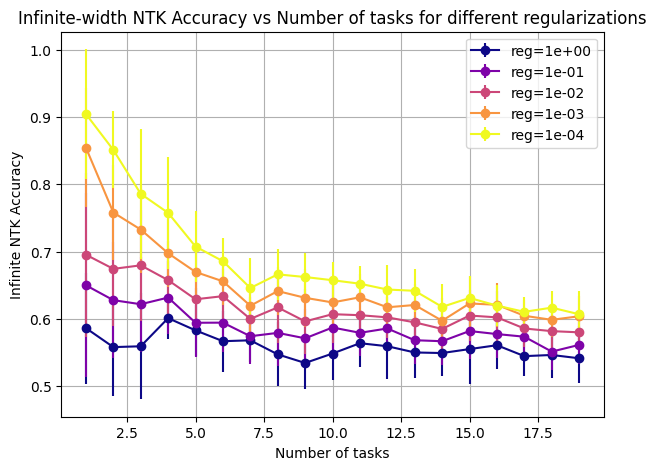

In [7]:
plt.figure(figsize=(7,5))
colors = cm.plasma(jnp.linspace(0, 1, len(regs)))

for i, reg_value in enumerate(regs):
    accs = final_results[reg_value]["accs_mean"]
    accs_std = final_results[reg_value]["accs_std"]
    plt.errorbar(
        possible_num_tasks, accs, yerr=accs_std, 
        marker='o', color=colors[i], label=f'reg={reg_value:.0e}'
    )

plt.xlabel('Number of tasks')
plt.ylabel('Infinite NTK Accuracy')
plt.title('Infinite-width NTK Accuracy vs Number of tasks for different regularizations')
plt.grid(True)
plt.legend()
plt.show()

In [8]:
# Hyperparameters
possible_num_tasks = range(1, 20)
num_seeds = 10
num_points_per_task = 64   # obtained from previous analysis
num_class = 2
data_dim = 2
num_centers = 20 ** data_dim
dim_hypercube = 2.0
centers_per_task = num_centers // possible_num_tasks[-1] - 1

# Regularization sweep
regs = [1e-4]

# Preallocate results
results = {
    reg_val: {"accs": [ [] for _ in possible_num_tasks ]} 
    for reg_val in regs
}

pbar_seeds = tqdm(range(num_seeds), desc="Seeds", leave=False)

for seed in pbar_seeds:
    pbar_seeds.set_description(f"Seed = {seed}")

    # Generate one dataset with the MAX number of tasks

    max_tasks = possible_num_tasks[-1]

    ds_full = make_multitask_classification_datasets(
        data_dim=data_dim,
        num_centers=num_centers,
        dim_hypercube=dim_hypercube, 
        num_class=num_class, 
        num_points_per_task=num_points_per_task, 
        num_tasks=max_tasks,
        centers_per_task=centers_per_task, 
        overlap=0.1, 
        random_state=seed,
        reuse=False
    )

    # Loop over num_tasks and regularization values
    
    for t_idx, num_tasks in enumerate(possible_num_tasks):

        # Select the first num_tasks tasks
        ds = ds_full[:num_tasks]

        # Create combined dataset
        X_all = jnp.vstack([task['X'] for task in ds])
        y_all = jnp.concatenate([task['y'] for task in ds])

        train_test = train_test_split(
            X_all, y_all, test_size=0.33, random_state=42
        )
        x_train, x_test, y_train, y_test = map(jnp.array, train_test)

        y_train = one_hot(y_train, num_class).astype(jnp.float32)
        y_test  = one_hot(y_test,  num_class).astype(jnp.float32)

        # Build model
        init_fn, apply_fn, kernel_fn = stax.serial(
            stax.Dense(10, W_std=1.5, b_std=0.05, parameterization="ntk"),
            stax.Erf(),
            stax.Dense(num_class, W_std=1.5, b_std=0.05, parameterization="ntk")
        )

        # Compute infinite NTK
        ntk_dict_inf = compute_infinite_ntk(kernel_fn, x_train, x_test)
        K_train_train_inf = ntk_dict_inf["train_train"]
        K_test_train_inf  = ntk_dict_inf["test_train"]

        # Expand kernels for multi-output
        def expand(K):
            return jnp.stack([
                jnp.stack([
                    K if i == j else jnp.zeros_like(K)
                    for j in range(num_class)
                ], axis=-1)
                for i in range(num_class)
            ], axis=-2)

        K_train_train_inf = expand(K_train_train_inf)
        K_test_train_inf  = expand(K_test_train_inf)

        # Loop over regularization sweep
        
        for reg_value in regs:

            # Infinite-width predictor
            predict_fn_inf = nt.predict.gradient_descent_mse(
                K_train_train_inf, y_train,
                diag_reg=reg_value, trace_axes=(),
                diag_reg_absolute_scale=False
            )

            fx_train_0_inf = jnp.zeros_like(y_train)
            fx_test_0_inf  = jnp.zeros_like(y_test)

            _, preds_test_inf = predict_fn_inf(
                t=None,
                fx_train_0=fx_train_0_inf,
                fx_test_0=fx_test_0_inf,
                k_test_train=K_test_train_inf
            )

            # Accuracy
            pred_labels = jnp.argmax(preds_test_inf, axis=-1)
            true_labels = jnp.argmax(y_test, axis=-1)
            acc = float(jnp.mean(pred_labels == true_labels))

            # Store accuracy *for this seed*
            results[reg_value]["accs"][t_idx].append(acc)

# Final aggregation: compute mean & std across seeds
final_results = {}
for reg in regs:
    mean_accs = [float(jnp.mean(jnp.array(acc_list)))
                 for acc_list in results[reg]["accs"]]
    std_accs  = [float(jnp.std(jnp.array(acc_list)))
                 for acc_list in results[reg]["accs"]]

    final_results[reg] = {
        "accs_mean": mean_accs,
        "accs_std":  std_accs
    }


Seed = 0:   0%|          | 0/10 [00:00<?, ?it/s]

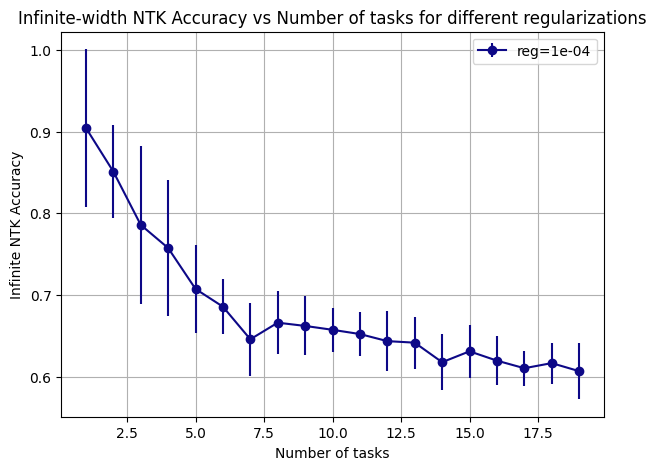

In [9]:
plt.figure(figsize=(7,5))
colors = cm.plasma(jnp.linspace(0, 1, len(regs)))

for i, reg_value in enumerate(regs):
    accs = final_results[reg_value]["accs_mean"]
    accs_std = final_results[reg_value]["accs_std"]
    plt.errorbar(
        possible_num_tasks, accs, yerr=accs_std, 
        marker='o', color=colors[i], label=f'reg={reg_value:.0e}'
    )

plt.xlabel('Number of tasks')
plt.ylabel('Infinite NTK Accuracy')
plt.title('Infinite-width NTK Accuracy vs Number of tasks for different regularizations')
plt.grid(True)
plt.legend()
plt.show()

These results are a bit surprising! One would think that, since the gaussians are unique to the tasks, having 2 tasks being trained to the network they would just look like 1 big task. Indeed they do, but the trick is that apparently having 2 times the training points is not enough to sustain the training of a task with twice the gaussians. Let's visualize it next.

# How does having twice the gaussians in the task affect training points needed?

In [14]:
num_class = 2
data_dim = 2
num_centers = 20 ** data_dim
possible_num_points = [15, 20, 30, 40, 50, 64, 128, 256, 512, 1024, 2048, 4096]
num_tasks = 15                      # Number of random seeds to avg data over
dim_hypercube = 2.0
centers_per_task = (num_centers//19)*2
reg = 1e-4

accs = []
accs_std = []

pbar = tqdm(possible_num_points, desc="Starting", leave=False)

for num_points_per_task in pbar:
    pbar.set_description(f"Running P = {num_points_per_task}")
    temp_accs = []

    for seed in range(num_tasks):

        # Generate dataset
        ds_list = make_multitask_classification_datasets(
            data_dim=data_dim,
            num_centers=num_centers,
            dim_hypercube=dim_hypercube,
            num_class=num_class,
            num_points_per_task=num_points_per_task,
            num_tasks=1,                     # One task only
            centers_per_task=centers_per_task,
            overlap=0.1,
            random_state=seed,
            reuse=False
        )

        ds = ds_list[0]                     # Extract the task
        X, y = ds['X'], ds['y']
        centers = ds['centers']
        sigma = ds['sigma']

        x_train, x_test, y_train, y_test = train_test_split(
            X, y, test_size=0.33, random_state=42
        )

        x_train, x_test = jnp.array(x_train), jnp.array(x_test)
        y_train, y_test = jnp.array(y_train), jnp.array(y_test)

        y_train = one_hot(y_train, num_class).astype(jnp.float32)
        y_test  = one_hot(y_test,  num_class).astype(jnp.float32)

        init_fn, apply_fn, kernel_fn = stax.serial(
            stax.Dense(10, W_std=1.5, b_std=0.05, parameterization="ntk"),
            stax.Erf(),
            stax.Dense(num_class, W_std=1.5, b_std=0.05, parameterization="ntk")
        )

        ntk_dict_inf = compute_infinite_ntk(kernel_fn, x_train, x_test)
        K_train_train_inf = ntk_dict_inf["train_train"]
        K_test_train_inf = ntk_dict_inf["test_train"]

        # Expand the kernels
        K_train_train_inf = jnp.stack([
            jnp.stack([
                K_train_train_inf if i == j else jnp.zeros_like(K_train_train_inf)
                for j in range(num_class)
            ], axis=-1)
            for i in range(num_class)
        ], axis=-2)

        K_test_train_inf = jnp.stack([
            jnp.stack([
                K_test_train_inf if i == j else jnp.zeros_like(K_test_train_inf)
                for j in range(num_class)
            ], axis=-1)
            for i in range(num_class)
        ], axis=-2)

        predict_fn_inf = nt.predict.gradient_descent_mse(
            K_train_train_inf, y_train,
            diag_reg=reg, trace_axes=(), diag_reg_absolute_scale=False
        )

        fx_train_0_inf = jnp.zeros_like(y_train)
        fx_test_0_inf = jnp.zeros_like(y_test)

        _, preds_test_inf = predict_fn_inf(
            t=None, fx_train_0=fx_train_0_inf, fx_test_0=fx_test_0_inf,
            k_test_train=K_test_train_inf
        )

        pred_labels_inf = jnp.argmax(preds_test_inf, axis=-1)
        true_labels = jnp.argmax(y_test, axis=-1)
        acc_inf = float(jnp.mean(pred_labels_inf == true_labels))

        temp_accs.append(acc_inf)

    accs.append(jnp.mean(jnp.array(temp_accs)))
    accs_std.append(jnp.std(jnp.array(temp_accs)))

    # Calculate the values for exactly 2*50 points
    accs_2=[]

    for seed in range(num_tasks):

        # Generate dataset
        ds_list = make_multitask_classification_datasets(
            data_dim=data_dim,
            num_centers=num_centers,
            dim_hypercube=dim_hypercube,
            num_class=num_class,
            num_points_per_task=2*50,        # Exact number of points
            num_tasks=1,                     # One task only
            centers_per_task=centers_per_task,
            overlap=0.1,
            random_state=seed,
            reuse=False
        )

        ds = ds_list[0]                     # Extract the task
        X, y = ds['X'], ds['y']
        centers = ds['centers']
        sigma = ds['sigma']

        x_train, x_test, y_train, y_test = train_test_split(
            X, y, test_size=0.33, random_state=42
        )

        x_train, x_test = jnp.array(x_train), jnp.array(x_test)
        y_train, y_test = jnp.array(y_train), jnp.array(y_test)

        y_train = one_hot(y_train, num_class).astype(jnp.float32)
        y_test  = one_hot(y_test,  num_class).astype(jnp.float32)

        init_fn, apply_fn, kernel_fn = stax.serial(
            stax.Dense(10, W_std=1.5, b_std=0.05, parameterization="ntk"),
            stax.Erf(),
            stax.Dense(num_class, W_std=1.5, b_std=0.05, parameterization="ntk")
        )

        ntk_dict_inf = compute_infinite_ntk(kernel_fn, x_train, x_test)
        K_train_train_inf = ntk_dict_inf["train_train"]
        K_test_train_inf = ntk_dict_inf["test_train"]

        # Expand the kernels
        K_train_train_inf = jnp.stack([
            jnp.stack([
                K_train_train_inf if i == j else jnp.zeros_like(K_train_train_inf)
                for j in range(num_class)
            ], axis=-1)
            for i in range(num_class)
        ], axis=-2)

        K_test_train_inf = jnp.stack([
            jnp.stack([
                K_test_train_inf if i == j else jnp.zeros_like(K_test_train_inf)
                for j in range(num_class)
            ], axis=-1)
            for i in range(num_class)
        ], axis=-2)

        predict_fn_inf = nt.predict.gradient_descent_mse(
            K_train_train_inf, y_train,
            diag_reg=reg, trace_axes=(), diag_reg_absolute_scale=False
        )

        fx_train_0_inf = jnp.zeros_like(y_train)
        fx_test_0_inf = jnp.zeros_like(y_test)

        _, preds_test_inf = predict_fn_inf(
            t=None, fx_train_0=fx_train_0_inf, fx_test_0=fx_test_0_inf,
            k_test_train=K_test_train_inf
        )

        pred_labels_inf = jnp.argmax(preds_test_inf, axis=-1)
        true_labels = jnp.argmax(y_test, axis=-1)
        acc_inf = float(jnp.mean(pred_labels_inf == true_labels))

        accs_2.append(acc_inf)
    
    acc_2 = (jnp.mean(jnp.array(accs_2)))
    acc_std_2 = (jnp.std(jnp.array(accs_2)))


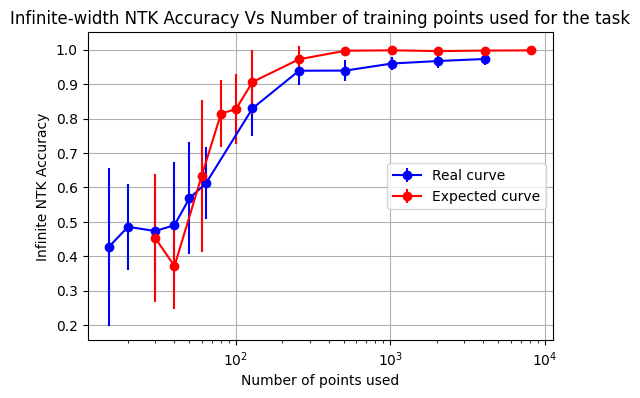

In [15]:
plt.figure(figsize=(6,4))
plt.errorbar(possible_num_points, accs, yerr=accs_std, marker='o',
             color='blue', label="Real curve")
plt.errorbar([x*2 for x in x_points_vs_acc], y_points_vs_acc, yerr=y_err_points_vs_acc, marker='o',
             color='red', label="Expected curve")
plt.xscale('log')
plt.xlabel('Number of points used')
plt.ylabel('Infinite NTK Accuracy')
plt.title('Infinite-width NTK Accuracy Vs Number of training points used for the task')
plt.grid(True)
plt.legend(loc="right")
plt.show()

As is obvious from this graph, the number of training points needed is increased with respect to what we expected.

It would be interesting to see how do these scale with number of centers used.

# How does number of points needed depend on number of gaussians included?

In [16]:
# But if I add one more task, and they are not using the same gaussians, I effectively
# have 1 task with double the gaussians.

num_class = 2
data_dim = 2
num_centers = 20 ** data_dim        # same as before
possible_num_points = [15, 20, 30, 40, 50, 64, 128, 256, 512, 1024, 2048, 4096]
centers_per_task_range=range(2, num_centers + 1, 8)
num_tasks = 15                      # number of random seeds / datasets
dim_hypercube = 2.0
reg = 1e-4

tot_accs=[]
tot_accs_std=[]

pbar_centers = tqdm(centers_per_task_range, desc="Starting", leave=False)

for centers_per_task in pbar_centers:

    pbar_centers.set_description(f"Running centers_per_task = {centers_per_task}")

    accs = []
    accs_std = []

    pbar_points = tqdm(possible_num_points, desc="Starting", leave=False)

    for num_points_per_task in pbar_points:
        pbar_points.set_description(f"Running P = {num_points_per_task}")
        temp_accs = []

        for seed in range(num_tasks):

            # Generate dataset
            ds_list = make_multitask_classification_datasets(
                data_dim=data_dim,
                num_centers=num_centers,
                dim_hypercube=dim_hypercube,
                num_class=num_class,
                num_points_per_task=num_points_per_task,
                num_tasks=1,                     # One task only
                centers_per_task=centers_per_task,
                overlap=0.1,
                random_state=seed,
                reuse=False
            )

            ds = ds_list[0]                     # Extract the task
            X, y = ds['X'], ds['y']
            centers = ds['centers']
            sigma = ds['sigma']

            x_train, x_test, y_train, y_test = train_test_split(
                X, y, test_size=0.33, random_state=42
            )

            x_train, x_test = jnp.array(x_train), jnp.array(x_test)
            y_train, y_test = jnp.array(y_train), jnp.array(y_test)

            y_train = one_hot(y_train, num_class).astype(jnp.float32)
            y_test  = one_hot(y_test,  num_class).astype(jnp.float32)

            init_fn, apply_fn, kernel_fn = stax.serial(
                stax.Dense(10, W_std=1.5, b_std=0.05, parameterization="ntk"),
                stax.Erf(),
                stax.Dense(num_class, W_std=1.5, b_std=0.05, parameterization="ntk")
            )

            ntk_dict_inf = compute_infinite_ntk(kernel_fn, x_train, x_test)
            K_train_train_inf = ntk_dict_inf["train_train"]
            K_test_train_inf = ntk_dict_inf["test_train"]

            # Expand the kernels
            K_train_train_inf = jnp.stack([
                jnp.stack([
                    K_train_train_inf if i == j else jnp.zeros_like(K_train_train_inf)
                    for j in range(num_class)
                ], axis=-1)
                for i in range(num_class)
            ], axis=-2)

            K_test_train_inf = jnp.stack([
                jnp.stack([
                    K_test_train_inf if i == j else jnp.zeros_like(K_test_train_inf)
                    for j in range(num_class)
                ], axis=-1)
                for i in range(num_class)
            ], axis=-2)

            predict_fn_inf = nt.predict.gradient_descent_mse(
                K_train_train_inf, y_train,
                diag_reg=reg, trace_axes=(), diag_reg_absolute_scale=False
            )

            fx_train_0_inf = jnp.zeros_like(y_train)
            fx_test_0_inf = jnp.zeros_like(y_test)

            _, preds_test_inf = predict_fn_inf(
                t=None, fx_train_0=fx_train_0_inf, fx_test_0=fx_test_0_inf,
                k_test_train=K_test_train_inf
            )

            pred_labels_inf = jnp.argmax(preds_test_inf, axis=-1)
            true_labels = jnp.argmax(y_test, axis=-1)
            acc_inf = float(jnp.mean(pred_labels_inf == true_labels))

            temp_accs.append(acc_inf)

        accs.append(jnp.mean(jnp.array(temp_accs)))
        accs_std.append(jnp.std(jnp.array(temp_accs)))

    tot_accs.append(accs)
    tot_accs_std.append(accs_std)


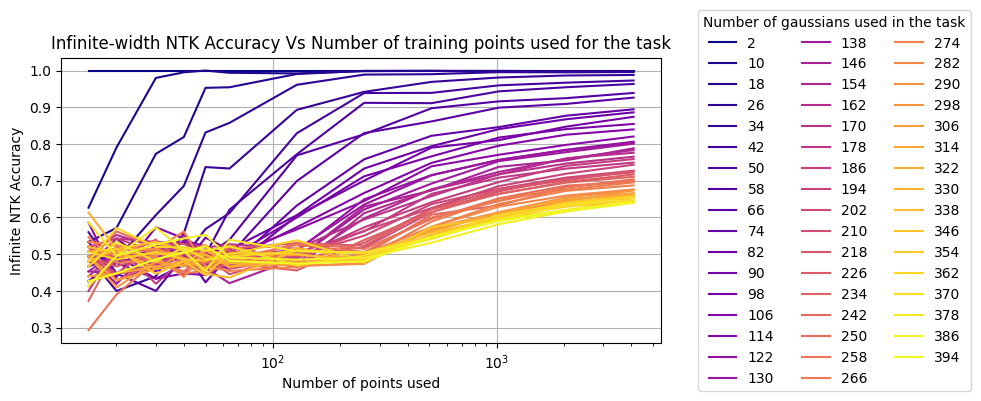

In [17]:
plt.figure(figsize=(10,4))

cmap = cm.plasma  # maybe "cool"?
num_curves = len(tot_accs)
colors = [cmap(i / (num_curves - 1)) for i in range(num_curves)]

for i, (accs, accs_std) in enumerate(zip(tot_accs, tot_accs_std)):
    plt.plot(
        possible_num_points, 
        accs,
        label=f"{centers_per_task_range[i]}",
        color=colors[i]
    )

plt.xscale('log')
plt.xlabel('Number of points used')
plt.ylabel('Infinite NTK Accuracy')
plt.title('Infinite-width NTK Accuracy Vs Number of training points used for the task')
plt.grid(True)

plt.legend(
    ncol=3, 
    bbox_to_anchor=(1.05, 0.5), 
    loc='center left', 
    title="Number of gaussians used in the task"
)

plt.tight_layout()
plt.show()


Repeat the code with a choice of number of points used that is geometric, to get a better analysis later

In [18]:
# But if I add one more task, and they are not using the same gaussians, I effectively
# have 1 task with double the gaussians.

num_class = 2
data_dim = 2
num_centers = 20 ** data_dim        # same as before
possible_num_points = [int(x) for x in jnp.geomspace(15,4000,30)]
centers_per_task_range=range(2, num_centers + 1, 8)
num_tasks = 15                      # number of random seeds / datasets
dim_hypercube = 2.0
reg = 1e-4

tot_accs=[]
tot_accs_std=[]

pbar_centers = tqdm(centers_per_task_range, desc="Starting", leave=False)

for centers_per_task in pbar_centers:

    pbar_centers.set_description(f"Running centers_per_task = {centers_per_task}")

    accs = []
    accs_std = []

    pbar_points = tqdm(possible_num_points, desc="Starting", leave=False)

    for num_points_per_task in pbar_points:
        pbar_points.set_description(f"Running P = {num_points_per_task}")
        temp_accs = []

        for seed in range(num_tasks):

            # Generate dataset
            ds_list = make_multitask_classification_datasets(
                data_dim=data_dim,
                num_centers=num_centers,
                dim_hypercube=dim_hypercube,
                num_class=num_class,
                num_points_per_task=num_points_per_task,
                num_tasks=1,                     # One task only
                centers_per_task=centers_per_task,
                overlap=0.1,
                random_state=seed,
                reuse=False
            )

            ds = ds_list[0]                     # Extract the task
            X, y = ds['X'], ds['y']
            centers = ds['centers']
            sigma = ds['sigma']

            x_train, x_test, y_train, y_test = train_test_split(
                X, y, test_size=0.33, random_state=42
            )

            x_train, x_test = jnp.array(x_train), jnp.array(x_test)
            y_train, y_test = jnp.array(y_train), jnp.array(y_test)

            y_train = one_hot(y_train, num_class).astype(jnp.float32)
            y_test  = one_hot(y_test,  num_class).astype(jnp.float32)

            init_fn, apply_fn, kernel_fn = stax.serial(
                stax.Dense(10, W_std=1.5, b_std=0.05, parameterization="ntk"),
                stax.Erf(),
                stax.Dense(num_class, W_std=1.5, b_std=0.05, parameterization="ntk")
            )

            ntk_dict_inf = compute_infinite_ntk(kernel_fn, x_train, x_test)
            K_train_train_inf = ntk_dict_inf["train_train"]
            K_test_train_inf = ntk_dict_inf["test_train"]

            # Expand the kernels
            K_train_train_inf = jnp.stack([
                jnp.stack([
                    K_train_train_inf if i == j else jnp.zeros_like(K_train_train_inf)
                    for j in range(num_class)
                ], axis=-1)
                for i in range(num_class)
            ], axis=-2)

            K_test_train_inf = jnp.stack([
                jnp.stack([
                    K_test_train_inf if i == j else jnp.zeros_like(K_test_train_inf)
                    for j in range(num_class)
                ], axis=-1)
                for i in range(num_class)
            ], axis=-2)

            predict_fn_inf = nt.predict.gradient_descent_mse(
                K_train_train_inf, y_train,
                diag_reg=reg, trace_axes=(), diag_reg_absolute_scale=False
            )

            fx_train_0_inf = jnp.zeros_like(y_train)
            fx_test_0_inf = jnp.zeros_like(y_test)

            _, preds_test_inf = predict_fn_inf(
                t=None, fx_train_0=fx_train_0_inf, fx_test_0=fx_test_0_inf,
                k_test_train=K_test_train_inf
            )

            pred_labels_inf = jnp.argmax(preds_test_inf, axis=-1)
            true_labels = jnp.argmax(y_test, axis=-1)
            acc_inf = float(jnp.mean(pred_labels_inf == true_labels))

            temp_accs.append(acc_inf)

        accs.append(jnp.mean(jnp.array(temp_accs)))
        accs_std.append(jnp.std(jnp.array(temp_accs)))

    tot_accs.append(accs)
    tot_accs_std.append(accs_std)


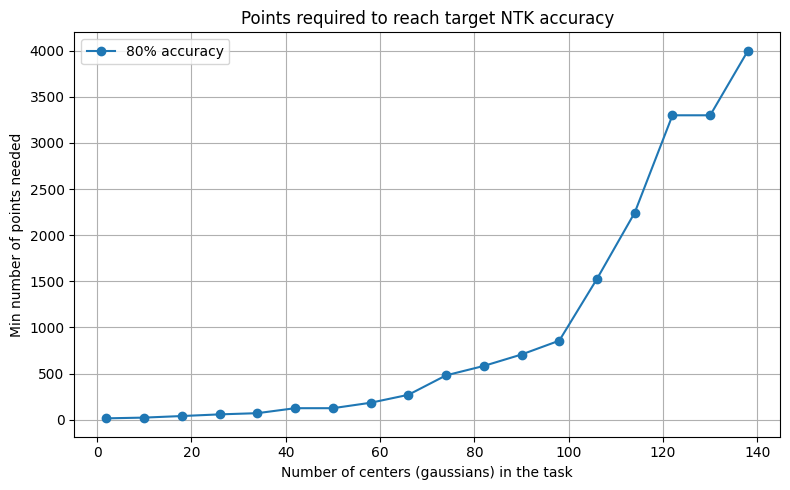

In [19]:
# thresholds
thresholds = [0.80]

# store results
required_points = {thr: [] for thr in thresholds}

# for each curve (i.e. number of centers)
for accs, centers in zip(tot_accs, centers_per_task_range):
    for thr in thresholds:
        # find the first number of points that achieves >= threshold
        idx = jnp.where(jnp.array(accs) >= thr)[0]
        if len(idx) > 0:
            required_points[thr].append(possible_num_points[idx[0]])
        else:
            # if threshold never reached, append NaN
            required_points[thr].append(jnp.nan)

# plot: number of centers vs number of points needed
plt.figure(figsize=(8,5))
for thr, color in zip(thresholds, ['tab:blue', 'tab:orange']):
    plt.plot(
        centers_per_task_range,
        required_points[thr],
        marker='o',
        label=f"{int(thr*100)}% accuracy",
        color=color
    )

#plt.yscale('log')
plt.xlabel('Number of centers (gaussians) in the task')
plt.ylabel('Min number of points needed')
plt.title('Points required to reach target NTK accuracy')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


The number of points needed to keep am 80% accuracy is exponential in the number of centers used per task, therefore just using a fixed number of points per task is not enough when you increase the number of them.

Let's try to see if the effect is caused (at least partly) by the number of points used, then.

In [12]:
possible_num_tasks = range(1, 20)
num_seeds = 10
num_class = 2
data_dim = 2
num_centers = 20**data_dim
dim_hypercube = 2.0
reg = 1e-4
centers_per_task = num_centers // possible_num_tasks[-1] - 1

# Different numbers of points per task to test
points_per_task_list = [50, 100, 200, 500, 700, 1000]

# Prepare results storage
results = {n: {'accs': [], 'accs_std': []} for n in points_per_task_list}

# ===========================================================
# REFACOTORED EXPERIMENT LOOP
# ===========================================================
for num_points_per_task in points_per_task_list:
    print(f"\n=== Running experiments for num_points_per_task = {num_points_per_task} ===")

    # Per-task accumulators across seeds
    accs_per_numtask = [[] for _ in possible_num_tasks]

    pbar_seeds = tqdm(range(num_seeds), desc="Seeds", leave=False)
    for seed in pbar_seeds:
        pbar_seeds.set_description(f"Points={num_points_per_task}, Seed={seed}")

        # --------------------------------------------------
        # (1) Generate ONE dataset with MAX num_tasks
        # --------------------------------------------------
        max_tasks = possible_num_tasks[-1]

        ds_full = make_multitask_classification_datasets(
            data_dim=data_dim,
            num_centers=num_centers,
            dim_hypercube=dim_hypercube,
            num_class=num_class,
            num_points_per_task=num_points_per_task,
            num_tasks=max_tasks,
            centers_per_task=centers_per_task,
            overlap=0.1,
            random_state=seed,
            reuse=False
        )

        # --------------------------------------------------
        # (2) Loop over num_tasks and train NTK models
        # --------------------------------------------------
        for t_idx, num_tasks in enumerate(possible_num_tasks):
            # Take first num_tasks tasks
            ds = ds_full[:num_tasks]

            # Combine tasks
            X_all = jnp.vstack([task['X'] for task in ds])
            y_all = jnp.concatenate([task['y'] for task in ds])

            # Train/test split
            x_train, x_test, y_train, y_test = train_test_split(
                X_all, y_all, test_size=0.33, random_state=42
            )

            x_train, x_test = jnp.array(x_train), jnp.array(x_test)
            y_train, y_test = jnp.array(y_train), jnp.array(y_test)

            # One-hot labels
            C = num_class
            y_train = one_hot(y_train, C).astype(jnp.float32)
            y_test  = one_hot(y_test,  C).astype(jnp.float32)

            # ----------------------------------------------
            # Build NTK network
            # ----------------------------------------------
            init_fn, apply_fn, kernel_fn = stax.serial(
                stax.Dense(10, W_std=1.5, b_std=0.05, parameterization="ntk"),
                stax.Relu(),
                stax.Dense(C, W_std=1.5, b_std=0.05, parameterization="ntk")
            )

            ntk_dict_inf = compute_infinite_ntk(kernel_fn, x_train, x_test)
            K_train_train_inf = ntk_dict_inf["train_train"]
            K_test_train_inf  = ntk_dict_inf["test_train"]

            # Independent outputs
            def expand(K):
                return jnp.stack([
                    jnp.stack([
                        K if i == j else jnp.zeros_like(K)
                        for j in range(C)
                    ], axis=-1)
                    for i in range(C)
                ], axis=-2)

            K_train_train_inf = expand(K_train_train_inf)
            K_test_train_inf  = expand(K_test_train_inf)

            # ----------------------------------------------
            # Infinite-width NTK predictor
            # ----------------------------------------------
            predict_fn_inf = nt.predict.gradient_descent_mse(
                K_train_train_inf, y_train,
                diag_reg=reg, trace_axes=(),
                diag_reg_absolute_scale=False
            )

            fx_train_0_inf = jnp.zeros_like(y_train)
            fx_test_0_inf  = jnp.zeros_like(y_test)

            _, preds_test_inf = predict_fn_inf(
                t=None,
                fx_train_0=fx_train_0_inf,
                fx_test_0=fx_test_0_inf,
                k_test_train=K_test_train_inf
            )

            # ----------------------------------------------
            # Accuracy
            # ----------------------------------------------
            pred_labels = jnp.argmax(preds_test_inf, axis=-1)
            true_labels = jnp.argmax(y_test, axis=-1)
            acc = float(jnp.mean(pred_labels == true_labels))

            accs_per_numtask[t_idx].append(acc)

    # After all seeds:
    mean_accs = [float(jnp.mean(jnp.array(acc_list))) for acc_list in accs_per_numtask]
    std_accs  = [float(jnp.std(jnp.array(acc_list)))  for acc_list in accs_per_numtask]

    results[num_points_per_task]['accs'] = mean_accs
    results[num_points_per_task]['accs_std'] = std_accs



=== Running experiments for num_points_per_task = 50 ===



=== Running experiments for num_points_per_task = 100 ===



=== Running experiments for num_points_per_task = 200 ===



=== Running experiments for num_points_per_task = 500 ===



=== Running experiments for num_points_per_task = 700 ===



=== Running experiments for num_points_per_task = 1000 ===


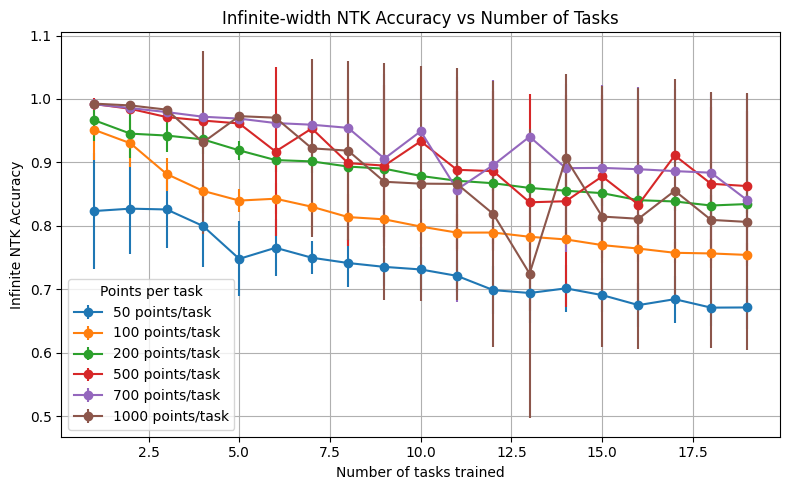

In [13]:
plt.figure(figsize=(8, 5))

for num_points_per_task, vals in results.items():
    plt.errorbar(possible_num_tasks, vals['accs'], yerr=vals['accs_std'],
                 marker='o', label=f'{num_points_per_task} points/task')

plt.xlabel('Number of tasks trained')
plt.ylabel('Infinite NTK Accuracy')
plt.title('Infinite-width NTK Accuracy vs Number of Tasks')
plt.grid(True)
plt.legend(title='Points per task')
plt.tight_layout()
plt.show()

In [14]:
possible_num_tasks = range(1, 20)
num_seeds = 10
num_class = 2
data_dim = 2
num_centers = 20**data_dim
dim_hypercube = 5.0
overlap=0.0001
centers_per_task = num_centers // possible_num_tasks[-1] - 1

# Different numbers of points per task to test
points_per_task_list = [50, 100, 200, 500, 700, 1000]

# Prepare results storage
results = {n: {'min_dists': [], 'min_dists_std': [], 'closest_pairs': []} 
           for n in points_per_task_list}

# ==============================================
# Main Loop
# ==============================================
for num_points_per_task in points_per_task_list:
    print(f"\n=== Running experiments for num_points_per_task = {num_points_per_task} ===")
    
    # Store results for each num_tasks across all seeds
    all_seeds_min_dists = {nt: [] for nt in possible_num_tasks}
    all_seeds_closest_pairs = {nt: [] for nt in possible_num_tasks}
    
    # Loop over seeds FIRST
    for seed in range(num_seeds):
        # Create FULL multitask dataset with ALL 19 tasks ONCE per seed
        ds_full = make_multitask_classification_datasets(
            data_dim=data_dim,
            num_centers=num_centers,
            dim_hypercube=dim_hypercube, 
            num_class=num_class, 
            num_points_per_task=num_points_per_task, 
            num_tasks=possible_num_tasks[-1],  # Always create 19 tasks
            centers_per_task=centers_per_task, 
            overlap=overlap, 
            random_state=seed,
            reuse=False
        )
        
        # Now loop over num_tasks and subset from this SAME dataset
        pbar = tqdm(possible_num_tasks, desc=f"Seed {seed}", leave=False)
        for num_tasks in pbar:
            pbar.set_description(f"num_points={num_points_per_task}, seed={seed}, num_tasks={num_tasks}")
            
            # Select only the FIRST num_tasks from the full dataset
            ds = ds_full[:num_tasks]
            
            # Combine selected tasks into a single dataset
            X_all = jnp.vstack([task['X'] for task in ds])
            y_all = jnp.concatenate([task['y'] for task in ds])
            
            # Train/test split
            x_train, x_test, y_train, y_test = train_test_split(
                X_all, y_all, test_size=0.33, random_state=42
            )
            
            # Convert to JAX arrays
            x_train = jnp.array(x_train)
            
            # Compute pairwise Euclidean distances
            x_squared = jnp.sum(x_train**2, axis=1, keepdims=True)
            dist_squared = x_squared + x_squared.T - 2 * jnp.dot(x_train, x_train.T)
            
            # Clamp negative values to zero (due to numerical precision)
            dist_squared = jnp.maximum(dist_squared, 0.0)
            dist_matrix = jnp.sqrt(dist_squared + 1e-10)
            
            # Set diagonal to inf to ignore self-distances
            dist_matrix = dist_matrix.at[jnp.diag_indices_from(dist_matrix)].set(jnp.inf)
            
            # Check for NaN or invalid values
            if jnp.any(jnp.isnan(dist_matrix)):
                print(f"\nWarning: NaN detected in distance matrix for num_tasks={num_tasks}, seed={seed}")
                continue
            
            # Find MINIMUM distance (closest pair)
            min_dist = float(jnp.min(dist_matrix))
            all_seeds_min_dists[num_tasks].append(min_dist)
            
            # Find the indices of the two closest points
            min_idx = jnp.unravel_index(jnp.argmin(dist_matrix), dist_matrix.shape)
            point1 = x_train[min_idx[0]]
            point2 = x_train[min_idx[1]]
            all_seeds_closest_pairs[num_tasks].append({
                'indices': min_idx,
                'point1': point1,
                'point2': point2,
                'distance': min_dist,
                'num_tasks': num_tasks,
                'seed': seed
            })
    
    # Aggregate results across seeds for each num_tasks
    min_dists = []
    min_dists_std = []
    closest_pairs = []
    
    for num_tasks in possible_num_tasks:
        if len(all_seeds_min_dists[num_tasks]) > 0:
            min_dists.append(jnp.mean(jnp.array(all_seeds_min_dists[num_tasks])))
            min_dists_std.append(jnp.std(jnp.array(all_seeds_min_dists[num_tasks])))
            # Store the closest pair from the first seed
            closest_pairs.append(all_seeds_closest_pairs[num_tasks][0])
        else:
            min_dists.append(jnp.nan)
            min_dists_std.append(jnp.nan)
            closest_pairs.append({'distance': jnp.nan, 'point1': None, 'point2': None})
    
    results[num_points_per_task]['min_dists'] = min_dists
    results[num_points_per_task]['min_dists_std'] = min_dists_std
    results[num_points_per_task]['closest_pairs'] = closest_pairs


=== Running experiments for num_points_per_task = 50 ===



=== Running experiments for num_points_per_task = 100 ===



=== Running experiments for num_points_per_task = 200 ===



=== Running experiments for num_points_per_task = 500 ===



=== Running experiments for num_points_per_task = 700 ===



=== Running experiments for num_points_per_task = 1000 ===


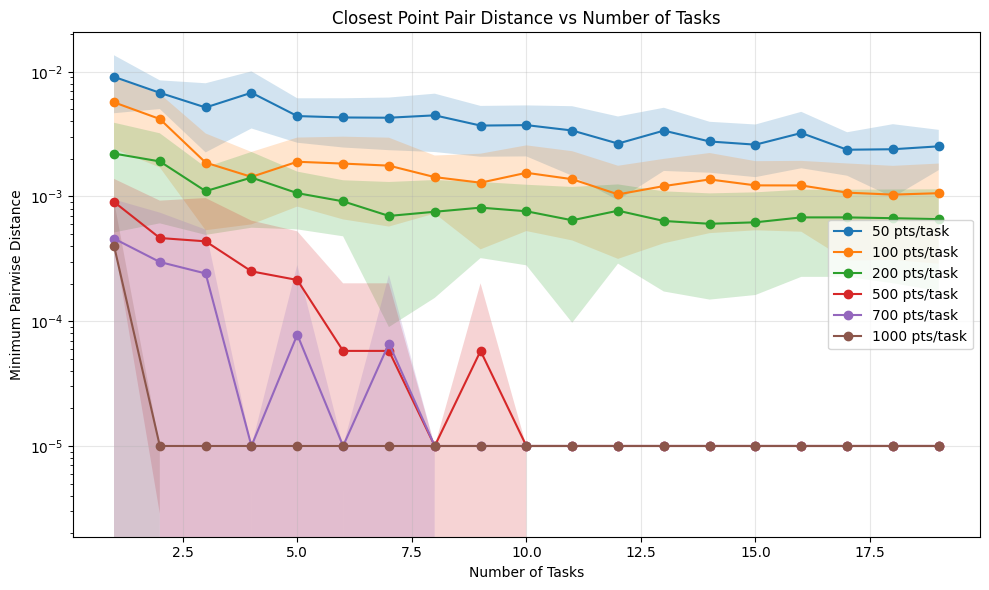


CLOSEST PAIRS (Minimum Distance) FOR EACH CONFIGURATION


Points per task: 50
----------------------------------------------------------------------------------------------------------------------------------
Num Tasks    Distance                  Point 1                                       Point 2                                      
----------------------------------------------------------------------------------------------------------------------------------
1            0.0089236712              [1.38544428, -1.38491130]                     [1.39376163, -1.38169670]                    
2            0.0085134804              [2.39958811, -1.37795925]                     [2.39139652, -1.37551677]                    
3            0.0089236712              [1.38544428, -1.38491130]                     [1.39376163, -1.38169670]                    
4            0.0106977103              [1.83883309, 1.61691356]                      [1.83230460, 1.60845065]                     
5   

In [15]:
# ==============================================
# Visualization
# ==============================================
fig, ax = plt.subplots(1, 1, figsize=(10, 6))

# Minimum Distance vs Number of Tasks
for num_points in points_per_task_list:
    min_dists = results[num_points]['min_dists']
    min_dists_std = results[num_points]['min_dists_std']
    ax.plot(possible_num_tasks, min_dists, marker='o', label=f'{num_points} pts/task')
    ax.fill_between(possible_num_tasks,
                     jnp.array(min_dists) - jnp.array(min_dists_std),
                     jnp.array(min_dists) + jnp.array(min_dists_std),
                     alpha=0.2)

ax.set_xlabel('Number of Tasks')
ax.set_ylabel('Minimum Pairwise Distance')
ax.set_title('Closest Point Pair Distance vs Number of Tasks')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_yscale('log')

plt.tight_layout()
plt.show()

# ==============================================
# Display Table of Closest Pairs
# ==============================================
print("\n" + "="*130)
print("CLOSEST PAIRS (Minimum Distance) FOR EACH CONFIGURATION")
print("="*130)

for num_points in points_per_task_list:
    print(f"\n\nPoints per task: {num_points}")
    print("-" * 130)
    print(f"{'Num Tasks':<12} {'Distance':<25} {'Point 1':<45} {'Point 2':<45}")
    print("-" * 130)
    
    for i, num_tasks in enumerate(possible_num_tasks):
        pair = results[num_points]['closest_pairs'][i]
        if pair['point1'] is not None:
            p1_str = f"[{', '.join([f'{x:.8f}' for x in pair['point1']])}]"
            p2_str = f"[{', '.join([f'{x:.8f}' for x in pair['point2']])}]"
            dist_str = f"{pair['distance']:.10f}"
        else:
            p1_str = "NaN"
            p2_str = "NaN"
            dist_str = "NaN"
        print(f"{num_tasks:<12} {dist_str:<25} {p1_str:<45} {p2_str:<45}")

In [3]:
##############################################################################
# Hyperparameters
##############################################################################
possible_num_tasks = range(1, 20)
num_seeds = 10
num_class = 2
data_dim = 2
num_centers = 20**data_dim
dim_hypercube = 2.0
reg = 1e-4
overlap = 0.0001
centers_per_task = num_centers // possible_num_tasks[-1] - 1

points_per_task_list = [50, 100, 200, 500, 700, 1000]

##############################################################################
# Storage: now includes ACCURACY + DISTANCE metrics
##############################################################################
results = {
    n: {
        'accs': [], 'accs_std': [],
        'min_dists': [], 'min_dists_std': [],
        'closest_pairs': []
    }
    for n in points_per_task_list
}

##############################################################################
# UNIFIED EXPERIMENT LOOP
##############################################################################
for num_points_per_task in points_per_task_list:
    print(f"\n=== Running experiments for num_points_per_task = {num_points_per_task} ===")

    # Storage indexed by num_tasks
    accs_per_numtask        = [[] for _ in possible_num_tasks]
    min_dists_per_numtask   = [[] for _ in possible_num_tasks]
    closest_pairs_per_numtask = [[] for _ in possible_num_tasks]

    ##########################################################################
    # Loop over seeds (GENERATE ONE MAX TASK DATASET per seed)
    ##########################################################################
    for seed in tqdm(range(num_seeds), desc="Seeds", leave=False):

        # Make full dataset with 19 tasks once per seed
        max_tasks = possible_num_tasks[-1]
        ds_full = make_multitask_classification_datasets(
            data_dim=data_dim,
            num_centers=num_centers,
            dim_hypercube=dim_hypercube,
            num_class=num_class,
            num_points_per_task=num_points_per_task,
            num_tasks=max_tasks,
            centers_per_task=centers_per_task,
            overlap=overlap,
            random_state=seed,
            reuse=False
        )

        ######################################################################
        # Loop over num_tasks = 1..19
        ######################################################################
        for t_idx, num_tasks in enumerate(possible_num_tasks):

            # Use only the FIRST num_tasks tasks
            ds = ds_full[:num_tasks]

            # Combine into single dataset
            X_all = jnp.vstack([task['X'] for task in ds])
            y_all = jnp.concatenate([task['y'] for task in ds])

            # Train/test split
            x_train, x_test, y_train, y_test = train_test_split(
                X_all, y_all, test_size=0.33, random_state=42
            )

            x_train = jnp.array(x_train)
            x_test  = jnp.array(x_test)
            y_train = jnp.array(y_train)
            y_test  = jnp.array(y_test)

            # One-hot encode
            C = num_class
            y_train_oh = one_hot(y_train, C).astype(jnp.float32)
            y_test_oh  = one_hot(y_test,  C).astype(jnp.float32)

            ##################################################################
            # ---------- DISTANCE ANALYSIS -----------------------------------
            ##################################################################
            # Compute pairwise distances
            x_sq = jnp.sum(x_train**2, axis=1, keepdims=True)
            dist_sq = x_sq + x_sq.T - 2 * (x_train @ x_train.T)
            dist_sq = jnp.maximum(dist_sq, 0.0)
            dist_matrix = jnp.sqrt(dist_sq + 1e-12)

            # Ignore diagonal
            dist_matrix = dist_matrix.at[jnp.diag_indices_from(dist_matrix)].set(jnp.inf)

            # Find minimum distance & closest pair
            min_dist = float(jnp.min(dist_matrix))
            pair_idx = jnp.unravel_index(jnp.argmin(dist_matrix), dist_matrix.shape)
            p1, p2 = x_train[pair_idx[0]], x_train[pair_idx[1]]

            min_dists_per_numtask[t_idx].append(min_dist)
            closest_pairs_per_numtask[t_idx].append({
                'indices': pair_idx,
                'point1': p1,
                'point2': p2,
                'distance': min_dist,
                'num_tasks': num_tasks,
                'seed': seed
            })

            ##################################################################
            # ---------- NTK Accuracy Analysis -------------------------------
            ##################################################################
            init_fn, apply_fn, kernel_fn = stax.serial(
                stax.Dense(10, W_std=1.5, b_std=0.05, parameterization="ntk"),
                stax.Relu(),
                stax.Dense(C,  W_std=1.5, b_std=0.05, parameterization="ntk")
            )

            ntk_dict = compute_infinite_ntk(kernel_fn, x_train, x_test)
            K_train = ntk_dict["train_train"]
            K_test  = ntk_dict["test_train"]

            # Expand for multiple outputs
            def expand(K):
                return jnp.stack([
                    jnp.stack([K if i == j else jnp.zeros_like(K)
                               for j in range(C)], axis=-1)
                    for i in range(C)
                ], axis=-2)

            K_train_exp = expand(K_train)
            K_test_exp  = expand(K_test)

            # NTK predictor
            predictor = nt.predict.gradient_descent_mse(
                K_train_exp, y_train_oh,
                diag_reg=reg,
                trace_axes=(),
                diag_reg_absolute_scale=False
            )

            fx0_train = jnp.zeros_like(y_train_oh)
            fx0_test  = jnp.zeros_like(y_test_oh)

            _, preds_test = predictor(
                t=None,
                fx_train_0=fx0_train,
                fx_test_0=fx0_test,
                k_test_train=K_test_exp
            )

            # Accuracy
            pred_labels = jnp.argmax(preds_test, axis=-1)
            true_labels = jnp.argmax(y_test_oh, axis=-1)
            acc = float(jnp.mean(pred_labels == true_labels))

            accs_per_numtask[t_idx].append(acc)

    ##########################################################################
    # Aggregate across seeds for this num_points_per_task
    ##########################################################################
    mean_accs     = [float(jnp.mean(jnp.array(lst))) for lst in accs_per_numtask]
    std_accs      = [float(jnp.std(jnp.array(lst)))  for lst in accs_per_numtask]

    mean_dists    = [float(jnp.mean(jnp.array(lst))) for lst in min_dists_per_numtask]
    std_dists     = [float(jnp.std(jnp.array(lst)))  for lst in min_dists_per_numtask]

    one_pair_per_ntask = [
        (closest_pairs_per_numtask[t][0] if len(closest_pairs_per_numtask[t]) > 0 else None)
        for t in range(len(possible_num_tasks))
    ]

    # Store into results
    results[num_points_per_task]['accs']      = mean_accs
    results[num_points_per_task]['accs_std']  = std_accs
    results[num_points_per_task]['min_dists'] = mean_dists
    results[num_points_per_task]['min_dists_std'] = std_dists
    results[num_points_per_task]['closest_pairs'] = one_pair_per_ntask



=== Running experiments for num_points_per_task = 50 ===



=== Running experiments for num_points_per_task = 100 ===



=== Running experiments for num_points_per_task = 200 ===



=== Running experiments for num_points_per_task = 500 ===



=== Running experiments for num_points_per_task = 700 ===



=== Running experiments for num_points_per_task = 1000 ===


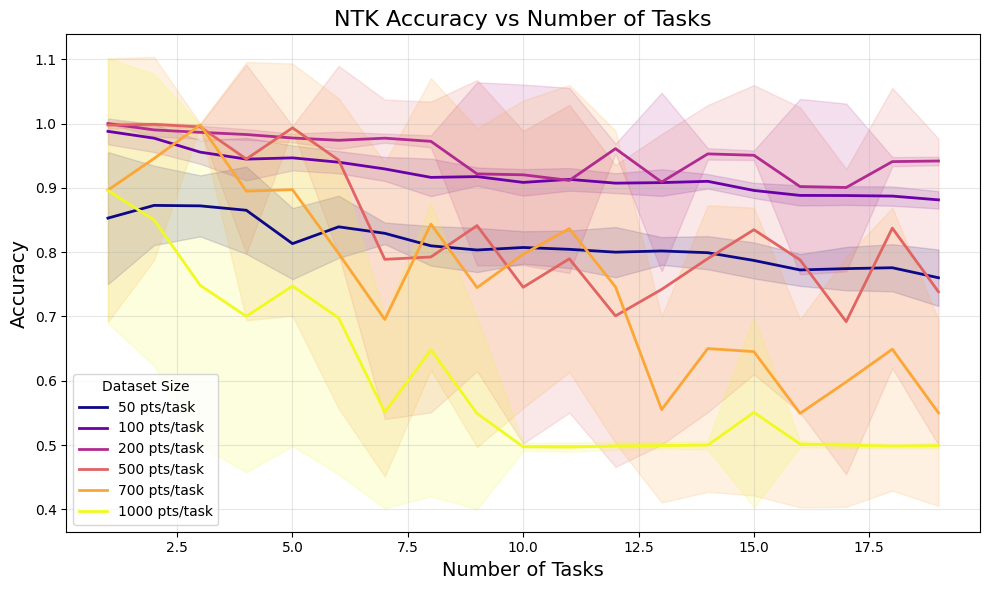

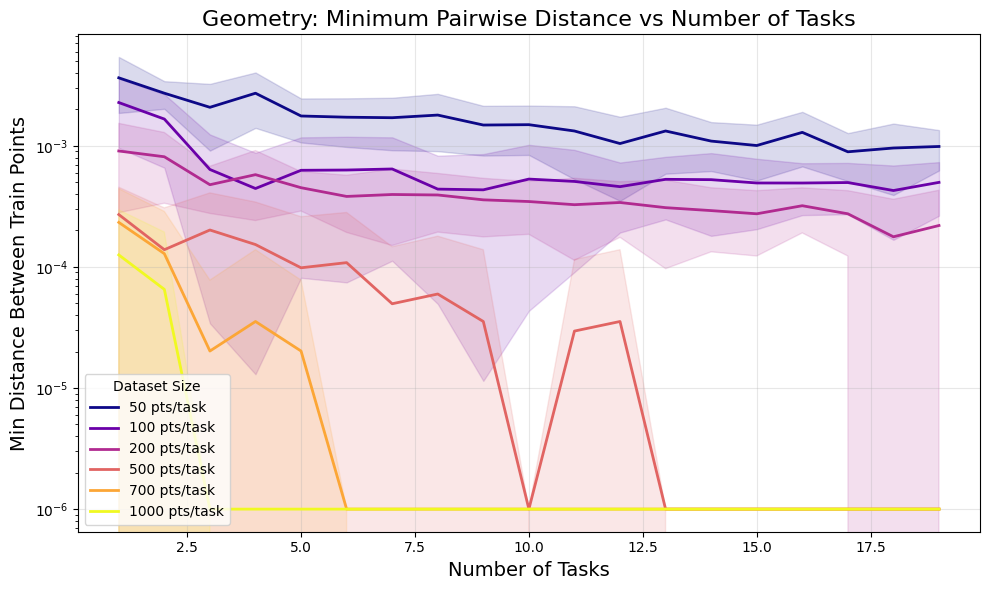

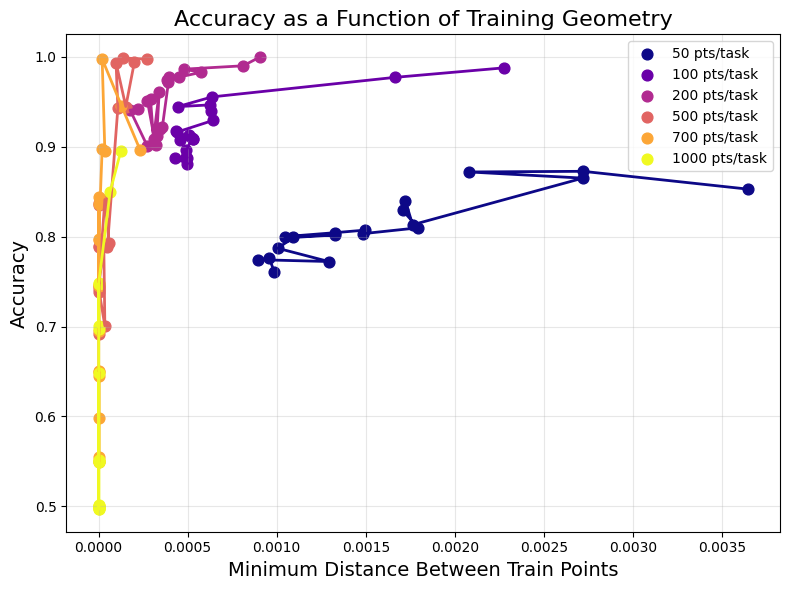

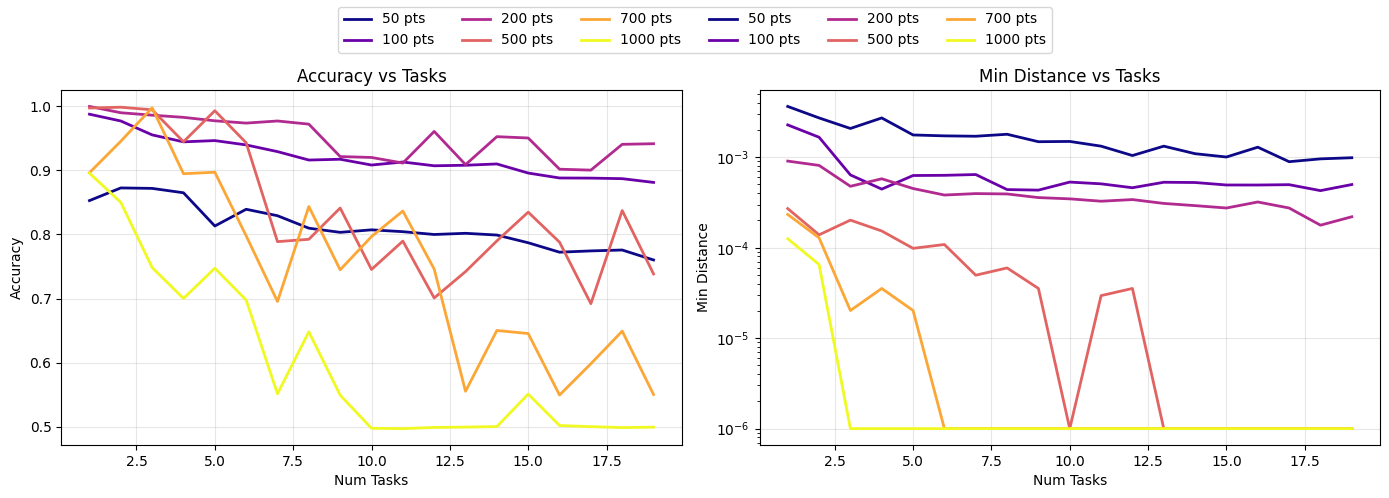

In [11]:
import numpy as np
import matplotlib.pyplot as plt

num_tasks_list = list(range(1, 20))

# Choose a consistent color palette
colors = plt.cm.plasma(np.linspace(0, 1, len(points_per_task_list)))

###############################################################################
# 1. ACCURACY vs NUM_TASKS
###############################################################################
plt.figure(figsize=(10, 6))

for i, npt in enumerate(points_per_task_list):
    accs = results[npt]['accs']
    accs_std = results[npt]['accs_std']
    
    plt.plot(num_tasks_list, accs, label=f"{npt} pts/task", color=colors[i], lw=2)
    plt.fill_between(num_tasks_list,
                     np.array(accs) - np.array(accs_std),
                     np.array(accs) + np.array(accs_std),
                     color=colors[i], alpha=0.15)

plt.xlabel("Number of Tasks", fontsize=14)
plt.ylabel("Accuracy", fontsize=14)
plt.title("NTK Accuracy vs Number of Tasks", fontsize=16)
plt.legend(title="Dataset Size")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


###############################################################################
# 2. MINIMUM DISTANCE vs NUM_TASKS
###############################################################################
plt.figure(figsize=(10, 6))

for i, npt in enumerate(points_per_task_list):
    dists = results[npt]['min_dists']
    dists_std = results[npt]['min_dists_std']
    
    plt.plot(num_tasks_list, dists, label=f"{npt} pts/task", color=colors[i], lw=2)
    plt.fill_between(num_tasks_list,
                     np.array(dists) - np.array(dists_std),
                     np.array(dists) + np.array(dists_std),
                     color=colors[i], alpha=0.15)


plt.yscale('log')
plt.xlabel("Number of Tasks", fontsize=14)
plt.ylabel("Min Distance Between Train Points", fontsize=14)
plt.title("Geometry: Minimum Pairwise Distance vs Number of Tasks", fontsize=16)
plt.legend(title="Dataset Size")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


###############################################################################
# 3. ACCURACY vs MIN_DISTANCE (Geometry → Generalization Link)
###############################################################################
plt.figure(figsize=(8, 6))

for i, npt in enumerate(points_per_task_list):
    accs  = np.array(results[npt]['accs'])
    dists = np.array(results[npt]['min_dists'])
    plt.scatter(dists, accs, s=60, color=colors[i], label=f"{npt} pts/task")
    plt.plot(dists, accs, color=colors[i], lw=2)

plt.xlabel("Minimum Distance Between Train Points", fontsize=14)
plt.ylabel("Accuracy", fontsize=14)
plt.title("Accuracy as a Function of Training Geometry", fontsize=16)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


###############################################################################
# 4. Multi-panel summary
###############################################################################
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left Panel: Accuracy vs Tasks
for i, npt in enumerate(points_per_task_list):
    axes[0].plot(num_tasks_list, results[npt]['accs'],
                 label=f"{npt} pts", color=colors[i], lw=2)

axes[0].set_title("Accuracy vs Tasks")
axes[0].set_xlabel("Num Tasks")
axes[0].set_ylabel("Accuracy")
axes[0].grid(alpha=0.3)

# Right Panel: Min Distance vs Tasks
for i, npt in enumerate(points_per_task_list):
    axes[1].plot(num_tasks_list, results[npt]['min_dists'],
                 label=f"{npt} pts", color=colors[i], lw=2)

axes[1].set_yscale('log')
axes[1].set_title("Min Distance vs Tasks")
axes[1].set_xlabel("Num Tasks")
axes[1].set_ylabel("Min Distance")
axes[1].grid(alpha=0.3)

# Shared legend
fig.legend(loc="upper center", ncol=len(points_per_task_list), fontsize=10)
plt.tight_layout(rect=[0, 0, 1, 0.9])
plt.show()


In [ ]:
possible_num_tasks = range(1, 20)
num_seeds = 10
num_class = 2
data_dim = 2
num_centers = 20**data_dim
dim_hypercube = 3.0
reg = 1e-4

# Different numbers of points per task to test
points_per_task_list = [50, 100, 200, 500, 700, 1000]

# Prepare results storage
results = {n: {'accs': [], 'accs_std': []} for n in points_per_task_list}

# ==============================================
# Main Loop
# ==============================================
for num_points_per_task in points_per_task_list:
    print(f"\n=== Running experiments for num_points_per_task = {num_points_per_task} ===")
    accs = []
    accs_std = []

    pbar = tqdm(possible_num_tasks, desc="Starting", leave=False)

    centers_per_task = num_centers // possible_num_tasks[-1] - 1

    for num_tasks in pbar:
        pbar.set_description(f"num_points={num_points_per_task}, num_tasks={num_tasks}")
        temp_accs = []

        for seed in range(num_seeds):
            # Create multitask dataset
            ds = make_multitask_classification_datasets(
                data_dim=data_dim,
                num_centers=num_centers,
                dim_hypercube=dim_hypercube, 
                num_class=num_class, 
                num_points_per_task=num_points_per_task, 
                num_tasks=num_tasks,
                centers_per_task=centers_per_task, 
                overlap=0.1, 
                random_state=seed,
                reuse=False
            )

            # Combine all tasks into a single dataset
            X_all = jnp.vstack([task['X'] for task in ds])
            y_all = jnp.concatenate([task['y'] for task in ds])

            # Train/test split
            x_train, x_test, y_train, y_test = train_test_split(
                X_all, y_all, test_size=0.33, random_state=42
            )

            # Convert to JAX arrays
            x_train, x_test = jnp.array(x_train), jnp.array(x_test)
            y_train, y_test = jnp.array(y_train), jnp.array(y_test)

            # One-hot encode labels
            C = num_class
            y_train = one_hot(y_train, C).astype(jnp.float32)
            y_test  = one_hot(y_test,  C).astype(jnp.float32)

            # Build infinite NTK network
            init_fn, apply_fn, kernel_fn = stax.serial(
                stax.Dense(10, W_std=1.5, b_std=0.05, parameterization="ntk"),
                stax.Relu(),
                stax.Dense(C, W_std=1.5, b_std=0.05, parameterization="ntk")
            )

            # Compute NTK matrices
            ntk_dict_inf = compute_infinite_ntk(kernel_fn, x_train, x_test)
            K_train_train_inf = ntk_dict_inf["train_train"]
            K_test_train_inf = ntk_dict_inf["test_train"]

            # Expand for independent classes
            K_train_train_inf = jnp.stack([
                jnp.stack([
                    K_train_train_inf if i == j else jnp.zeros_like(K_train_train_inf)
                    for j in range(C)
                ], axis=-1)
                for i in range(C)
            ], axis=-2)

            K_test_train_inf = jnp.stack([
                jnp.stack([
                    K_test_train_inf if i == j else jnp.zeros_like(K_test_train_inf)
                    for j in range(C)
                ], axis=-1)
                for i in range(C)
            ], axis=-2)

            # Infinite-width predictor
            predict_fn_inf = nt.predict.gradient_descent_mse(
                K_train_train_inf, y_train,
                diag_reg=reg, trace_axes=(), diag_reg_absolute_scale=False
            )

            fx_train_0_inf = jnp.zeros_like(y_train)
            fx_test_0_inf = jnp.zeros_like(y_test)

            _, preds_test_inf = predict_fn_inf(
                t=None, fx_train_0=fx_train_0_inf, fx_test_0=fx_test_0_inf,
                k_test_train=K_test_train_inf
            )

            # Accuracy
            pred_labels_inf = jnp.argmax(preds_test_inf, axis=-1)
            true_labels = jnp.argmax(y_test, axis=-1)
            acc_inf = float(jnp.mean(pred_labels_inf == true_labels))

            temp_accs.append(acc_inf)

        accs.append(jnp.mean(jnp.array(temp_accs)))
        accs_std.append(jnp.std(jnp.array(temp_accs)))

    results[num_points_per_task]['accs'] = accs
    results[num_points_per_task]['accs_std'] = accs_std

In [5]:
possible_num_tasks = range(1, 20)
num_seeds = 10
num_class = 2
data_dim = 2
num_centers = 20**data_dim
dim_hypercube = 3.0
reg = 1e-4

# Different numbers of points per task to test
points_per_task_list = [200]

# Prepare results storage
results = {n: {'accs': [], 'accs_std': []} for n in points_per_task_list}

# ==============================================
# Main Loop
# ==============================================
for num_points_per_task in points_per_task_list:
    print(f"\n=== Running experiments for num_points_per_task = {num_points_per_task} ===")
    accs = []
    accs_std = []

    pbar = tqdm(possible_num_tasks, desc="Starting", leave=False)

    centers_per_task = num_centers // possible_num_tasks[-1] - 1

    for num_tasks in pbar:
        pbar.set_description(f"num_points={num_points_per_task}, num_tasks={num_tasks}")
        temp_accs = []

        for seed in range(num_seeds):
            # Create multitask dataset
            ds = make_multitask_classification_datasets(
                data_dim=data_dim,
                num_centers=num_centers,
                dim_hypercube=dim_hypercube, 
                num_class=num_class, 
                num_points_per_task=num_points_per_task, 
                num_tasks=num_tasks,
                centers_per_task=centers_per_task, 
                overlap=0.1, 
                random_state=seed,
                reuse=False
            )

            # Combine all tasks into a single dataset
            X_all = jnp.vstack([task['X'] for task in ds])
            y_all = jnp.concatenate([task['y'] for task in ds])

            # Train/test split
            x_train, x_test, y_train, y_test = train_test_split(
                X_all, y_all, test_size=0.33, random_state=42
            )

            # Convert to JAX arrays
            x_train, x_test = jnp.array(x_train), jnp.array(x_test)
            y_train, y_test = jnp.array(y_train), jnp.array(y_test)

            # One-hot encode labels
            C = num_class
            y_train = one_hot(y_train, C).astype(jnp.float32)
            y_test  = one_hot(y_test,  C).astype(jnp.float32)

            # Build infinite NTK network
            init_fn, apply_fn, kernel_fn = stax.serial(
                stax.Dense(10, W_std=1.5, b_std=0.05, parameterization="ntk"),
                stax.Relu(),
                stax.Dense(C, W_std=1.5, b_std=0.05, parameterization="ntk")
            )

            # Compute NTK matrices
            ntk_dict_inf = compute_infinite_ntk(kernel_fn, x_train, x_test)
            K_train_train_inf = ntk_dict_inf["train_train"]
            K_test_train_inf = ntk_dict_inf["test_train"]

            # Expand for independent classes
            K_train_train_inf = jnp.stack([
                jnp.stack([
                    K_train_train_inf if i == j else jnp.zeros_like(K_train_train_inf)
                    for j in range(C)
                ], axis=-1)
                for i in range(C)
            ], axis=-2)

            K_test_train_inf = jnp.stack([
                jnp.stack([
                    K_test_train_inf if i == j else jnp.zeros_like(K_test_train_inf)
                    for j in range(C)
                ], axis=-1)
                for i in range(C)
            ], axis=-2)

            # Infinite-width predictor
            predict_fn_inf = nt.predict.gradient_descent_mse(
                K_train_train_inf, y_train,
                diag_reg=reg, trace_axes=(), diag_reg_absolute_scale=False
            )

            fx_train_0_inf = jnp.zeros_like(y_train)
            fx_test_0_inf = jnp.zeros_like(y_test)

            _, preds_test_inf = predict_fn_inf(
                t=None, fx_train_0=fx_train_0_inf, fx_test_0=fx_test_0_inf,
                k_test_train=K_test_train_inf
            )

            # Accuracy
            pred_labels_inf = jnp.argmax(preds_test_inf, axis=-1)
            true_labels = jnp.argmax(y_test, axis=-1)
            acc_inf = float(jnp.mean(pred_labels_inf == true_labels))

            temp_accs.append(acc_inf)

        accs.append(jnp.mean(jnp.array(temp_accs)))
        accs_std.append(jnp.std(jnp.array(temp_accs)))

    results[num_points_per_task]['accs'] = accs
    results[num_points_per_task]['accs_std'] = accs_std


=== Running experiments for num_points_per_task = 200 ===


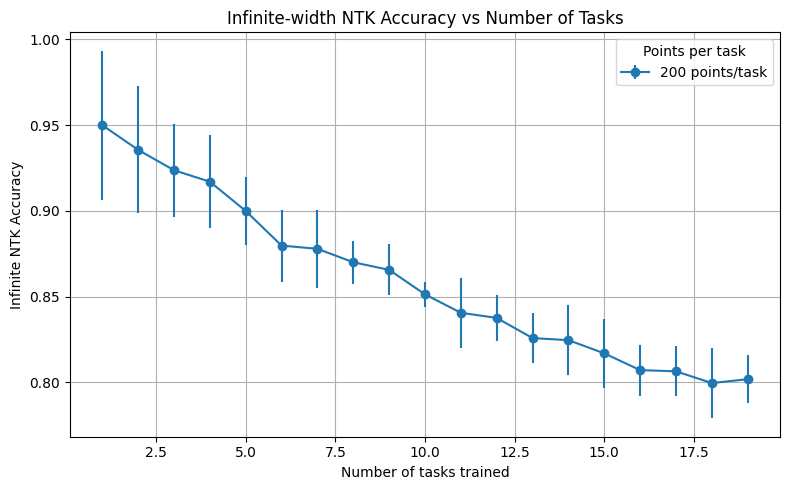

In [6]:
plt.figure(figsize=(8, 5))

for num_points_per_task, vals in results.items():
    plt.errorbar(possible_num_tasks, vals['accs'], yerr=vals['accs_std'],
                 marker='o', label=f'{num_points_per_task} points/task')

plt.xlabel('Number of tasks trained')
plt.ylabel('Infinite NTK Accuracy')
plt.title('Infinite-width NTK Accuracy vs Number of Tasks')
plt.grid(True)
plt.legend(title='Points per task')
plt.tight_layout()
plt.show()

In [21]:
# Hyperparameters
possible_num_tasks = range(1, 30)
num_seeds = 10  # Number of random seeds to average over
num_class = 2
data_dim = 2
num_centers = 20**data_dim
dim_hypercube = 2.0
centers_per_task = num_centers//possible_num_tasks[-1] -1
reg = 1e-4

possible_num_points_per_task = [50,100,200,300,400,500,600,700,800,900,1000]

tot_accs = []
tot_accs_std = []

pbar_points = tqdm(possible_num_points_per_task, desc="Starting", leave=False)

for num_points_per_task in pbar_points:

    pbar_points.set_description(f"Running num_points_per_task = {num_points_per_task}")

    accs = []
    accs_std = []

    pbar_tasks = tqdm(possible_num_tasks, desc="Starting", leave=False)

    for num_tasks in pbar_tasks:

        pbar_tasks.set_description(f"Running num_tasks = {num_tasks}")
        temp_accs = []

        for seed in range(num_seeds):

            # Create multitask dataset
            ds = make_multitask_classification_datasets(
                data_dim=data_dim,
                num_centers=num_centers,
                dim_hypercube=dim_hypercube, 
                num_class=num_class, 
                num_points_per_task=num_points_per_task, 
                num_tasks=num_tasks,
                centers_per_task=centers_per_task, 
                overlap=0.1, 
                random_state=seed,
                reuse=False
            )

            # Combine all tasks into a single dataset
            X_all = jnp.vstack([task['X'] for task in ds])
            y_all = jnp.concatenate([task['y'] for task in ds])

            # Train/test split
            x_train, x_test, y_train, y_test = train_test_split(X_all, y_all, test_size=0.33, random_state=42)

            # Convert to JAX arrays
            x_train, x_test = jnp.array(x_train), jnp.array(x_test)
            y_train, y_test = jnp.array(y_train), jnp.array(y_test)

            # One-hot encode labels
            C = num_class
            y_train = one_hot(y_train, C).astype(jnp.float32)
            y_test  = one_hot(y_test,  C).astype(jnp.float32)

            # Build infinite NTK network
            init_fn, apply_fn, kernel_fn = stax.serial(
                stax.Dense(10, W_std=1.5, b_std=0.05, parameterization="ntk"),
                stax.Erf(),
                stax.Dense(C, W_std=1.5, b_std=0.05, parameterization="ntk")
            )

            # Compute NTK matrices
            ntk_dict_inf = compute_infinite_ntk(kernel_fn, x_train, x_test)
            K_train_train_inf = ntk_dict_inf["train_train"]
            K_test_train_inf = ntk_dict_inf["test_train"]

            # Expand for multiple outputs (independent classes)
            K_train_train_inf = jnp.stack([
                jnp.stack([
                    K_train_train_inf if i == j else jnp.zeros_like(K_train_train_inf)
                    for j in range(C)
                ], axis=-1)
                for i in range(C)
            ], axis=-2)

            K_test_train_inf = jnp.stack([
                jnp.stack([
                    K_test_train_inf if i == j else jnp.zeros_like(K_test_train_inf)
                    for j in range(C)
                ], axis=-1)
                for i in range(C)
            ], axis=-2)

            # Infinite-width gradient descent predictor
            predict_fn_inf = nt.predict.gradient_descent_mse(
                K_train_train_inf, y_train,
                diag_reg=reg, trace_axes=(), diag_reg_absolute_scale=False
            )

            # Predict at infinite time (converged)
            fx_train_0_inf = jnp.zeros_like(y_train)
            fx_test_0_inf = jnp.zeros_like(y_test)

            _, preds_test_inf = predict_fn_inf(
                t=None, fx_train_0=fx_train_0_inf, fx_test_0=fx_test_0_inf,
                k_test_train=K_test_train_inf
            )

            # Compute accuracy
            pred_labels_inf = jnp.argmax(preds_test_inf, axis=-1)
            true_labels = jnp.argmax(y_test, axis=-1)
            acc_inf = float(jnp.mean(pred_labels_inf == true_labels))

            temp_accs.append(acc_inf)

        accs.append(jnp.mean(jnp.array(temp_accs)))
        accs_std.append(jnp.std(jnp.array(temp_accs)))
    
    tot_accs.append(accs)
    tot_accs_std.append(accs_std)


KeyboardInterrupt: 

In [ ]:
plt.figure(figsize=(10,4))

cmap = cm.plasma  # maybe "cool"?
num_curves = len(tot_accs)
colors = [cmap(i / (num_curves - 1)) for i in range(num_curves)]

for i, (accs, accs_std) in enumerate(zip(tot_accs, tot_accs_std)):
    plt.plot(
        possible_num_tasks, 
        accs,
        label=f"{possible_num_points_per_task[i]}",
        color=colors[i]
    )

plt.xlabel('Number of tasks trained')
plt.ylabel('Infinite NTK Accuracy')
plt.title('Infinite-width NTK Accuracy Vs Number of tasks trained for different numbers of points for each task')
plt.grid(True)

plt.legend(
    ncol=3, 
    bbox_to_anchor=(1.05, 0.5), 
    loc='center left', 
    title="Number of points per task"
)

plt.tight_layout()
plt.show()


In [ ]:
# Maybe the switch point around 11 tasks means that with too many points it starts to overfit (although it's always 66% traina dn 33% test)

In [ ]:
# Hyperparameters
possible_num_tasks = range(1, 20)
num_seeds = 10  # Number of random seeds to average over
num_class = 2
data_dim = 2
num_centers = 20**data_dim
dim_hypercube = 2.0
centers_per_task = num_centers//possible_num_tasks[-1] -1
reg = 1e-4

possible_num_points_per_task = [50,100,200,300,400,500,600,700,800,900,1000]

tot_test_means = []
tot_test_stds  = []
tot_train_means = []
tot_train_stds  = []
tot_ratio_means = []
tot_ratio_stds  = []

pbar_points = tqdm(possible_num_points_per_task, desc="Starting", leave=False)

for num_points_per_task in pbar_points:

    pbar_points.set_description(f"Running num_points_per_task = {num_points_per_task}")
    
    test_means = []
    test_stds  = []
    train_means = []
    train_stds  = []
    ratio_means = []
    ratio_stds  = []

    pbar_tasks = tqdm(possible_num_tasks, desc="Starting", leave=False)

    for num_tasks in pbar_tasks:

        pbar_tasks.set_description(f"Running num_tasks = {num_tasks}")

        test_accs_per_seed = []
        train_accs_per_seed = []

        for seed in range(num_seeds):
            
            ds = make_multitask_classification_datasets(
                data_dim=data_dim,
                num_centers=num_centers,
                dim_hypercube=dim_hypercube, 
                num_class=num_class, 
                num_points_per_task=num_points_per_task, 
                num_tasks=num_tasks,
                centers_per_task=centers_per_task, 
                overlap=0.1, 
                random_state=seed,
                reuse=False
            )

            X_all = jnp.vstack([task['X'] for task in ds])
            y_all = jnp.concatenate([task['y'] for task in ds])

            x_train, x_test, y_train_raw, y_test_raw = train_test_split(
                X_all, y_all, test_size=0.33, random_state=42
            )

            x_train, x_test = jnp.array(x_train), jnp.array(x_test)
            y_train = one_hot(jnp.array(y_train_raw), num_class).astype(jnp.float32)
            y_test  = one_hot(jnp.array(y_test_raw),  num_class).astype(jnp.float32)

            # build network and compute NTK
            init_fn, apply_fn, kernel_fn = stax.serial(
                stax.Dense(10, W_std=1.5, b_std=0.05, parameterization="ntk"),
                stax.Erf(),
                stax.Dense(num_class, W_std=1.5, b_std=0.05, parameterization="ntk")
            )

            ntk_dict_inf = compute_infinite_ntk(kernel_fn, x_train, x_test)
            K_train_train_inf = ntk_dict_inf["train_train"]
            K_test_train_inf  = ntk_dict_inf["test_train"]

            # expand for multiple outputs (C x C block diag)
            C = num_class
            K_train_train_inf = jnp.stack([
                jnp.stack([K_train_train_inf if i==j else jnp.zeros_like(K_train_train_inf)
                           for j in range(C)], axis=-1)
                for i in range(C)
            ], axis=-2)

            K_test_train_inf = jnp.stack([
                jnp.stack([K_test_train_inf if i==j else jnp.zeros_like(K_test_train_inf)
                           for j in range(C)], axis=-1)
                for i in range(C)
            ], axis=-2)

            # predictor
            predict_fn_inf = nt.predict.gradient_descent_mse(
                K_train_train_inf, y_train, diag_reg=reg, trace_axes=(), diag_reg_absolute_scale=False
            )

            fx_train_0_inf = jnp.zeros_like(y_train)
            fx_test_0_inf  = jnp.zeros_like(y_test)

            
            preds_train_inf, preds_test_inf = predict_fn_inf(
                t=None, fx_train_0=fx_train_0_inf, fx_test_0=fx_test_0_inf,
                k_test_train=K_test_train_inf
            )

            # compute accuracies
            pred_labels_test  = jnp.argmax(preds_test_inf, axis=-1)
            true_labels_test  = jnp.argmax(y_test, axis=-1)
            acc_test = float(jnp.mean(pred_labels_test == true_labels_test))

            pred_labels_train = jnp.argmax(preds_train_inf, axis=-1)
            true_labels_train = jnp.argmax(y_train, axis=-1)
            acc_train = float(jnp.mean(pred_labels_train == true_labels_train))

            test_accs_per_seed.append(acc_test)
            train_accs_per_seed.append(acc_train)

        # aggregate across seeds for this (num_points_per_task, num_tasks)
        test_means.append(jnp.mean(jnp.array(test_accs_per_seed)))
        test_stds.append(jnp.std(jnp.array(test_accs_per_seed)))
        train_means.append(jnp.mean(jnp.array(train_accs_per_seed)))
        train_stds.append(jnp.std(jnp.array(train_accs_per_seed)))

        # compute ratio per-seed then aggregate (more robust)
        ratios = jnp.array(test_accs_per_seed) / (jnp.array(train_accs_per_seed) + 1e-12)
        ratio_means.append(jnp.mean(ratios))
        ratio_stds.append(jnp.std(ratios))

    tot_test_means.append(test_means)
    tot_test_stds.append(test_stds)
    tot_train_means.append(train_means)
    tot_train_stds.append(train_stds)
    tot_ratio_means.append(ratio_means)
    tot_ratio_stds.append(ratio_stds)

# Convert to arrays: dims -> (len(points), len(tasks))
tot_test_means = jnp.array(tot_test_means)
tot_test_stds  = jnp.array(tot_test_stds)
tot_train_means= jnp.array(tot_train_means)
tot_train_stds = jnp.array(tot_train_stds)
tot_ratio_means = jnp.array(tot_ratio_means)
tot_ratio_stds  = jnp.array(tot_ratio_stds)

# --- Plotting: for a subset of num_tasks (or all if you like)
plt.figure(figsize=(12, 6))
for idx, num_tasks in enumerate(possible_num_tasks):
    plt.errorbar(possible_num_points_per_task,
                 tot_ratio_means[:, idx],
                 yerr=tot_ratio_stds[:, idx],
                 label=f"{num_tasks} tasks",
                 marker='o',
                 capsize=3,
                 alpha=0.8)

plt.xlabel("num_points_per_task")
plt.ylabel("test / train accuracy")
plt.title("Test/Train accuracy ratio vs num_points_per_task")
plt.legend(ncol=2, bbox_to_anchor=(1.02, 1), loc='upper left', fontsize='small')
plt.grid(True)
plt.tight_layout()
plt.show()

# Optional: also plot train and test accuracies side-by-side for the suspicious num_tasks
suspicious = 11  # the one you mentioned
idx = list(possible_num_tasks).index(suspicious)
plt.figure(figsize=(10,5))
plt.errorbar(possible_num_points_per_task, tot_train_means[:, idx], yerr=tot_train_stds[:, idx], marker='o', label='train')
plt.errorbar(possible_num_points_per_task, tot_test_means[:,  idx], yerr=tot_test_stds[:,  idx], marker='s', label='test')
plt.xlabel("num_points_per_task")
plt.ylabel("accuracy")
plt.title(f"Train vs Test accuracy (num_tasks={suspicious})")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(10,6))

# tot_test_means shape: (len(possible_num_points_per_task), len(possible_num_tasks))
for i, num_points in enumerate(possible_num_points_per_task):
    plt.errorbar(
        possible_num_tasks,
        tot_train_means[i],
        yerr=tot_train_stds[i],
        label=f"{num_points} pts/task",
        marker='o',
        capsize=3,
        alpha=0.8
    )

plt.xlabel("Number of Tasks")
plt.ylabel("Train Accuracy")
plt.title("Train Accuracy vs Number of Tasks (curves = data per task)")
plt.legend(ncol=2, bbox_to_anchor=(1.02, 1), loc='upper left', fontsize='small')
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(10,6))

# tot_test_means shape: (len(possible_num_points_per_task), len(possible_num_tasks))
for i, num_points in enumerate(possible_num_points_per_task):
    plt.errorbar(
        possible_num_tasks,
        tot_test_means[i],
        yerr=tot_test_stds[i],
        label=f"{num_points} pts/task",
        marker='o',
        capsize=3,
        alpha=0.8
    )

plt.xlabel("Number of Tasks")
plt.ylabel("Test Accuracy")
plt.title("Test Accuracy vs Number of Tasks (curves = data per task)")
plt.legend(ncol=2, bbox_to_anchor=(1.02, 1), loc='upper left', fontsize='small')
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
plt.figure(figsize=(10,6))

for i, num_points in enumerate(possible_num_points_per_task):
    plt.errorbar(
        possible_num_tasks,
        tot_ratio_means[i],
        yerr=tot_ratio_stds[i],
        label=f"{num_points} pts/task",
        marker='o',
        capsize=3,
        alpha=0.8
    )

plt.xlabel("Number of Tasks")
plt.ylabel("Test / Train Accuracy Ratio")
plt.title("Generalization Ratio vs Number of Tasks (curves = data per task)")
plt.legend(ncol=2, bbox_to_anchor=(1.02, 1), loc='upper left', fontsize='small')
plt.grid(True)
plt.tight_layout()
plt.show()
